# Notebook 00.1 — Cierre y Validación Final de la Auditoría de Datasets

Proyecto: **Reconocimiento Acústico de Vehículos de Emergencia**.

Esta notebook cierra la auditoría física de AudioSet-EV v2, LSSiren, sireNNet y A3Siren-Recordings. No rehace el EDA, no entrena modelos y no elige un dataset principal.

Se ejecuta en Kaggle, sobre `/kaggle/input`. No lee los CSV de la Notebook 00: inventario, cabeceras, hashes y cruces se calculan de nuevo. La salida queda en `/kaggle/working/dataset_audit_final/`.

No escribe archivos Markdown. `a3siren_independence_report.md` y `final_audit_report.md` se redactan después, con los CSV y los outputs de esta corrida. No modifica `/kaggle/input`.


## 01. Configuración

Semilla 42. Las rutas de entrada son las de Kaggle. Si una ruta canónica no está, la notebook busca la huella del dataset dentro de `/kaggle/input` y no inventa una ruta.


In [1]:
from __future__ import annotations

# Cierre de auditoría. No reutiliza CSV de la Notebook 00.
# No escribe archivos Markdown. No modifica /kaggle/input.

import hashlib
import json
import math
import os
import re
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import soundfile as sf
except ImportError:
    sf = None

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

INPUT_ROOT = Path("/kaggle/input")
OUTPUT_ROOT = Path("/kaggle/working/dataset_audit_final")
AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
CHUNK_SIZE = 100_000
HASH_CHUNK = 1024 * 1024
FRAME_ABS_TOL = 0.05
FRAME_REL_TOL = 0.01

DATASET_ORDER = ["audioset_ev", "lssiren", "sirennet", "a3siren"]
DISPLAY_NAMES = {
    "audioset_ev": "AudioSet-EV v2",
    "lssiren": "LSSiren",
    "sirennet": "sireNNet",
    "a3siren": "A3Siren-Recordings",
}
CANONICAL_ROOTS = {
    "audioset_ev": Path("/kaggle/input/datasets/jeancdevx/audioset-ev"),
    "lssiren": Path("/kaggle/input/datasets/jeancdevx/lssiren/lssiren"),
    "sirennet": Path("/kaggle/input/datasets/jeancdevx/sirennet/sireNNet"),
    "a3siren": Path("/kaggle/input/datasets/jeancdevx/a3s-rec"),
}
SIREN_FOLDERS = ("ambulance", "firetruck", "police", "traffic")
LSSIREN_FOLDERS = ("Emergency Vehicle Sirens", "Road Noises")
POLARITY_FOLDERS = ("Positive_files", "Negative_files")
SEGMENT_FOLDERS = ("balanced_train", "eval", "unbalanced", "unbalanced_train")
TOKEN_RE = re.compile(
    r"(?i)(?:^|[_\-\s])(aug|augmented|augmentation|doppler|copy|duplicate|original)(?:$|[_\-\s\d])"
)
NOISE_RE = re.compile(r"(?i)(?:^|[_\-\s])noise(?:$|[_\-\s\d])")
SIBLING_RE = re.compile(r"(?i)^sound_(\d+)_(\d+)$")
CHANNEL_RE = re.compile(r"(?i)^ch(\d+)$")
FILE_CHANNEL_RE = re.compile(r"(?i)-ch(\d+)$")
RISK_RANK = {"HIGH": 3, "MEDIUM": 2, "LOW": 1, "UNRESOLVED": 0}

STATE: dict = {}


def configure(input_root: Path | None = None, output_root: Path | None = None) -> None:
    """Fija rutas de esta corrida. La salida es solo /kaggle/working/dataset_audit_final."""
    global INPUT_ROOT, OUTPUT_ROOT
    INPUT_ROOT = Path("/kaggle/input") if input_root is None else Path(input_root)
    OUTPUT_ROOT = Path("/kaggle/working/dataset_audit_final") if output_root is None else Path(output_root)
    (OUTPUT_ROOT / "plots").mkdir(parents=True, exist_ok=True)
    STATE.clear()
    STATE["configured_at"] = datetime.now(timezone.utc).isoformat()
    STATE["seed"] = RANDOM_SEED
    print(f"input: {INPUT_ROOT}")
    print(f"output: {OUTPUT_ROOT}")
    print(f"seed: {RANDOM_SEED}")
    print("Esta corrida no lee CSV de la Notebook 00. Los vuelve a calcular desde /kaggle/input.")
    print("Esta corrida no escribe archivos Markdown.")


def export_table(frame: pd.DataFrame, filename: str, alias: str | None = None) -> Path:
    if filename.endswith(".md") or (alias or "").endswith(".md"):
        raise RuntimeError("Esta notebook no genera archivos Markdown.")
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_ROOT / filename
    frame.to_csv(path, index=False)
    print(f"escrito: {path}")
    if alias:
        alias_path = OUTPUT_ROOT / alias
        frame.to_csv(alias_path, index=False)
        print(f"alias: {alias_path}")
    return path


def show_df(frame: pd.DataFrame, n: int = 20) -> None:
    print(f"filas: {len(frame)} | columnas: {len(frame.columns)}")
    if frame.empty:
        print("(tabla vacía)")
        return
    display(frame.head(n))


def _display(dataset_id: str) -> str:
    return DISPLAY_NAMES[dataset_id]


def _is_ancestor(parent: Path, child: Path) -> bool:
    try:
        child.resolve().relative_to(parent.resolve())
    except ValueError:
        return False
    return parent.resolve() != child.resolve()


def _audio_count(root: Path) -> int:
    total = 0
    for _dirpath, dirnames, filenames in os.walk(root, followlinks=False):
        dirnames.sort()
        total += sum(1 for name in filenames if Path(name).suffix.lower() in AUDIO_EXTENSIONS)
    return total


In [2]:
def discover_roots(input_root: Path) -> dict[str, dict]:
    """Localiza las cuatro familias por ruta conocida o por huella. No inventa una ruta ausente."""
    found: dict[str, list[tuple[Path, str]]] = {key: [] for key in DATASET_ORDER}
    for dataset_id, canonical in CANONICAL_ROOTS.items():
        if canonical.exists():
            found[dataset_id].append((canonical, "ruta canónica de esta notebook"))
    if input_root.exists():
        for dirpath, dirnames, filenames in os.walk(input_root, followlinks=False):
            current = Path(dirpath)
            dirnames.sort()
            names = set(filenames)
            folded = {name.casefold(): name for name in filenames}
            if {"ev_positives.csv", "ev_negatives.csv"} <= set(folded):
                found["audioset_ev"].append((current, "EV_Positives.csv + EV_Negatives.csv"))
            if {"ambulance_final.csv", "road_final.csv"} <= set(folded):
                found["lssiren"].append((current, "Ambulance_final.csv + Road_final.csv"))
            child_fold = {name.casefold() for name in dirnames}
            if set(SIREN_FOLDERS) <= child_fold:
                found["sirennet"].append((current, "subcarpetas ambulance, firetruck, police, traffic"))
            if re.search(r"a3siren-recordings|a3s-rec|a3siren", current.name, re.IGNORECASE):
                found["a3siren"].append((current, f"nombre de carpeta: {current.name}"))
    selected = {}
    for dataset_id in DATASET_ORDER:
        candidates = []
        seen = set()
        for root, evidence in found[dataset_id]:
            key = str(root.resolve()) if root.exists() else str(root)
            if key in seen:
                continue
            seen.add(key)
            candidates.append({"root": root, "evidence": evidence, "files": _audio_count(root) if root.exists() else 0})
        if not candidates:
            selected[dataset_id] = {"root": None, "evidence": "no encontrado bajo /kaggle/input", "files": 0}
            continue
        kept = []
        for candidate in candidates:
            dominated = False
            for other in candidates:
                if other is candidate:
                    continue
                if _is_ancestor(candidate["root"], other["root"]) and candidate["files"] == other["files"]:
                    dominated = True
                    break
            if not dominated:
                kept.append(candidate)
        kept.sort(key=lambda item: (-item["files"], len(item["root"].parts), str(item["root"])))
        best = kept[0]
        selected[dataset_id] = best
    return selected


def build_inventory(roots: dict[str, dict]) -> pd.DataFrame:
    rows = []
    for dataset_id in DATASET_ORDER:
        root = roots[dataset_id]["root"]
        if root is None:
            continue
        for dirpath, dirnames, filenames in os.walk(root, followlinks=False):
            dirnames.sort()
            filenames.sort()
            for name in filenames:
                path = Path(dirpath) / name
                if path.suffix.lower() not in AUDIO_EXTENSIONS:
                    continue
                try:
                    size = path.stat().st_size
                except OSError:
                    size = None
                relative = path.relative_to(root).as_posix()
                parent = Path(relative).parent
                directory = "" if str(parent) == "." else parent.as_posix()
                rows.append(
                    {
                        "dataset_id": dataset_id,
                        "dataset": _display(dataset_id),
                        "relative_path": relative,
                        "filename": path.name,
                        "extension": path.suffix.lower(),
                        "file_size_bytes": size,
                        "file_size_mb": None if size is None else size / (1024 ** 2),
                        "directory": directory,
                        "possible_label_from_directory": "" if directory == "" else Path(directory).name,
                        "absolute_path": str(path),
                    }
                )
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame["file_size_bytes"] = pd.to_numeric(frame["file_size_bytes"], errors="coerce").astype("Int64")
    return frame.sort_values(["dataset", "relative_path"]).reset_index(drop=True)


def _audio_template(**kwargs: object) -> dict:
    base = {
        "sampling_rate_hz": None,
        "channels": None,
        "duration_seconds": None,
        "frames": None,
        "format": "",
        "subtype": "",
        "read_status": "ERROR",
        "error_message": "",
    }
    base.update(kwargs)
    return base


In [3]:
def inspect_audio_file(path: Path, file_size: int | None) -> dict:
    """Lee solo la cabecera. No carga el waveform."""
    if file_size == 0:
        return _audio_template(error_message="archivo vacío (0 bytes)")
    if sf is not None:
        try:
            info = sf.info(str(path))
            return _audio_template(
                sampling_rate_hz=int(info.samplerate) if info.samplerate else None,
                channels=int(info.channels) if info.channels else None,
                duration_seconds=float(info.duration) if info.duration is not None else None,
                frames=int(info.frames) if info.frames is not None else None,
                format=str(info.format or ""),
                subtype=str(info.subtype or ""),
                read_status="OK",
                error_message="",
            )
        except Exception as exc:
            soundfile_error = f"soundfile: {type(exc).__name__}: {exc}"
    else:
        soundfile_error = "soundfile no está instalado"
    probed = _inspect_ffprobe(path)
    if probed and probed["read_status"] == "OK":
        return probed
    if probed and probed.get("error_message"):
        return _audio_template(error_message=f"{soundfile_error}; {probed['error_message']}")
    return _audio_template(error_message=soundfile_error)


def _inspect_ffprobe(path: Path) -> dict | None:
    command = ["ffprobe", "-v", "error", "-print_format", "json", "-show_streams", "-show_format", str(path)]
    try:
        completed = subprocess.run(command, check=False, capture_output=True, text=True, timeout=30)
    except (FileNotFoundError, subprocess.TimeoutExpired, OSError):
        return None
    if completed.returncode != 0:
        return _audio_template(error_message=f"ffprobe: {(completed.stderr or '').strip()}")
    try:
        payload = json.loads(completed.stdout or "{}")
    except json.JSONDecodeError:
        return _audio_template(error_message="ffprobe: JSON ilegible")
    streams = [item for item in payload.get("streams") or [] if item.get("codec_type", "audio") == "audio"]
    stream = streams[0] if streams else {}
    fmt = payload.get("format") or {}
    def _num(value: object, cast=float):
        try:
            if value in (None, "", "N/A"):
                return None
            return cast(float(value))
        except (TypeError, ValueError):
            return None
    return _audio_template(
        sampling_rate_hz=_num(stream.get("sample_rate"), int),
        channels=_num(stream.get("channels"), int),
        duration_seconds=_num(stream.get("duration") or fmt.get("duration"), float),
        frames=_num(stream.get("nb_samples"), int),
        format=str(fmt.get("format_name") or ""),
        subtype=str(stream.get("bits_per_raw_sample") or stream.get("codec_name") or ""),
        read_status="OK" if stream or fmt else "ERROR",
        error_message="" if stream or fmt else "ffprobe no devolvió stream",
    )


def collect_headers(inventory: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for record in tqdm(inventory.itertuples(index=False), total=len(inventory), desc="cabeceras"):
        try:
            meta = inspect_audio_file(Path(record.absolute_path), None if pd.isna(record.file_size_bytes) else int(record.file_size_bytes))
        except Exception as exc:
            meta = _audio_template(error_message=f"{type(exc).__name__}: {exc}")
        meta.update(
            {
                "dataset": record.dataset,
                "dataset_id": record.dataset_id,
                "relative_path": record.relative_path,
                "filename": record.filename,
                "file_size_bytes": record.file_size_bytes,
            }
        )
        rows.append(meta)
    frame = pd.DataFrame(rows)
    for column in ("sampling_rate_hz", "channels", "frames", "file_size_bytes"):
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce").astype("Int64")
    frame["duration_seconds"] = pd.to_numeric(frame["duration_seconds"], errors="coerce")
    return frame


def quality_status(row: pd.Series) -> tuple[str, str]:
    issues = []
    status = "OK"
    size = row.get("file_size_bytes")
    duration = row.get("duration_seconds")
    rate = row.get("sampling_rate_hz")
    channels = row.get("channels")
    frames = row.get("frames")
    if row.get("read_status") != "OK":
        issues.append("unreadable")
        status = "ERROR"
    if pd.notna(size) and float(size) == 0:
        issues.append("empty_file")
        status = "ERROR"
    if row.get("read_status") == "OK" and (pd.isna(duration) or float(duration) <= 0):
        issues.append("non_positive_duration")
        status = "ERROR"
    if row.get("read_status") == "OK" and (pd.isna(rate) or float(rate) <= 0):
        issues.append("invalid_sampling_rate")
        status = "ERROR"
    if row.get("read_status") == "OK" and (pd.isna(channels) or float(channels) <= 0):
        issues.append("invalid_channels")
        status = "ERROR"
    if status != "ERROR" and pd.notna(duration) and pd.notna(rate) and pd.notna(frames) and float(rate) > 0:
        expected = float(frames) / float(rate)
        tolerance = max(FRAME_ABS_TOL, FRAME_REL_TOL * max(float(duration), expected))
        if abs(expected - float(duration)) > tolerance:
            issues.append("frame_duration_inconsistency")
            status = "WARNING"
    if not issues:
        issues.append("none")
    return status, "|".join(issues)


def apply_quality(headers: pd.DataFrame) -> pd.DataFrame:
    statuses = []
    codes = []
    for row in headers.itertuples(index=False):
        status, code = quality_status(pd.Series(row._asdict()))
        statuses.append(status)
        codes.append(code)
    frame = headers.copy()
    frame["quality_status"] = statuses
    frame["issue_codes"] = codes
    return frame


In [4]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            block = handle.read(HASH_CHUNK)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def build_manifest(inventory: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for record in tqdm(inventory.itertuples(index=False), total=len(inventory), desc="sha256"):
        try:
            digest = sha256_file(Path(record.absolute_path))
            error = ""
        except Exception as exc:
            digest = ""
            error = f"{type(exc).__name__}: {exc}"
        rows.append(
            {
                "dataset": record.dataset,
                "dataset_id": record.dataset_id,
                "relative_path": record.relative_path,
                "filename": record.filename,
                "file_size_bytes": record.file_size_bytes,
                "sha256": digest,
                "hash_error": error,
            }
        )
    return pd.DataFrame(rows)


def _match_column(columns: list[str], names: list[str]) -> str | None:
    folded = {str(column).casefold(): column for column in columns}
    for name in names:
        if name.casefold() in folded:
            return folded[name.casefold()]
    for column in columns:
        lowered = str(column).casefold()
        for name in names:
            if name.casefold() in lowered:
                return column
    return None


def _classify_downloaded_series(series: pd.Series) -> pd.Series:
    output = pd.Series("other", index=series.index, dtype="object")
    output[series.isna()] = "null"
    text = series.fillna("").astype(str).str.strip().str.casefold()
    output[text.eq("")] = "null"
    output[text.isin(["true", "1", "yes", "y"])] = "true"
    output[text.isin(["false", "0", "no", "n"])] = "false"
    return output


def _stem_series(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip().map(lambda value: Path(value).stem if value else "")


def choose_id_column(sample: pd.DataFrame, physical_stems: set[str]) -> tuple[str | None, str]:
    named = _match_column(list(sample.columns), ["yt_id", "youtube_id", "video_id", "yid"])
    if named:
        return named, "nombre de columna"
    best_column = None
    best_rate = 0.0
    for column in sample.columns:
        stems = _stem_series(sample[column])
        rate = float(stems.isin(physical_stems).mean()) if len(stems) else 0.0
        if rate > best_rate:
            best_rate = rate
            best_column = column
    if best_column is not None and best_rate > 0:
        return best_column, f"coincidencia con nombres de archivo en la muestra ({best_rate:.2%})"
    return None, "no identificada"


In [5]:
def scan_audioset_csv(path: Path, side: str, physical_stems: set[str]) -> dict:
    """Un solo recorrido por chunks. No conserva las filas que no corresponden a un archivo físico."""
    preview = pd.read_csv(path, nrows=5)
    print(f"\n{path.name} — columnas: {list(preview.columns)}")
    print(preview.dtypes.to_string())
    print("primeras filas:")
    display(preview)
    id_column, id_reason = choose_id_column(preview, physical_stems)
    columns = [str(column) for column in preview.columns]
    downloaded_column = _match_column(columns, ["downloaded", "download"])
    segment_column = _match_column(columns, ["segment_type", "segment"])
    label_column = _match_column(columns, ["positive_labels", "labels", "label"])
    start_column = _match_column(columns, ["start_seconds", "start_time", "start"])
    end_column = _match_column(columns, ["end_seconds", "end_time", "end"])
    print(
        f"columnas usadas: id={id_column} ({id_reason}); downloaded={downloaded_column}; "
        f"segment_type={segment_column}; labels={label_column}; start={start_column}; end={end_column}"
    )
    if id_column is None:
        raise RuntimeError(f"No se identificó una columna de id en {path.name}. Columnas: {columns}")
    usecols = [column for column in [id_column, downloaded_column, segment_column, label_column, start_column, end_column] if column]
    downloaded_counts: Counter = Counter()
    raw_downloaded: Counter = Counter()
    segment_counts: Counter = Counter()
    segment_download: Counter = Counter()
    null_downloaded = 0
    total_rows = 0
    matched: dict[str, dict] = {}
    conflicts = []
    reader = pd.read_csv(path, dtype=str, chunksize=CHUNK_SIZE, usecols=usecols, encoding="utf-8")
    for chunk in tqdm(reader, desc=path.name):
        total_rows += len(chunk)
        if downloaded_column:
            classes = _classify_downloaded_series(chunk[downloaded_column])
            downloaded_counts.update(classes.value_counts().to_dict())
            null_downloaded += int(chunk[downloaded_column].isna().sum())
            raw_downloaded.update(chunk[downloaded_column].fillna("<NA>").astype(str).value_counts().to_dict())
        else:
            classes = pd.Series("null", index=chunk.index)
        segment_values = chunk[segment_column].fillna("<NA>").astype(str) if segment_column else pd.Series("<NA>", index=chunk.index)
        segment_counts.update(segment_values.value_counts().to_dict())
        if downloaded_column:
            paired = list(zip(segment_values.tolist(), classes.tolist()))
            segment_download.update(paired)
        stems = _stem_series(chunk[id_column])
        mask = stems.isin(physical_stems)
        if not mask.any():
            continue
        subset = chunk.loc[mask].copy()
        subset_stems = stems.loc[mask]
        subset_class = classes.loc[mask]
        subset_segment = segment_values.loc[mask]
        for index, stem in subset_stems.items():
            payload = {
                "yt_id": "" if pd.isna(subset.at[index, id_column]) else str(subset.at[index, id_column]).strip(),
                "downloaded_raw": "" if not downloaded_column or pd.isna(subset.at[index, downloaded_column]) else str(subset.at[index, downloaded_column]),
                "downloaded_class": str(subset_class.at[index]),
                "segment_type": str(subset_segment.at[index]),
                "positive_labels": "" if not label_column or pd.isna(subset.at[index, label_column]) else str(subset.at[index, label_column]),
                "start_seconds": "" if not start_column or pd.isna(subset.at[index, start_column]) else str(subset.at[index, start_column]),
                "end_seconds": "" if not end_column or pd.isna(subset.at[index, end_column]) else str(subset.at[index, end_column]),
                "csv_name": path.name,
                "side": side,
            }
            previous = matched.get(stem)
            if previous is None:
                matched[stem] = payload
            elif previous.get("positive_labels") != payload["positive_labels"] or previous.get("csv_name") != payload["csv_name"]:
                conflicts.append(stem)
                payload["conflict"] = True
                matched[stem] = payload
    return {
        "side": side,
        "path": str(path),
        "total_rows": total_rows,
        "downloaded_counts": downloaded_counts,
        "raw_downloaded": raw_downloaded,
        "null_downloaded": null_downloaded,
        "segment_counts": segment_counts,
        "segment_download": segment_download,
        "matched": matched,
        "conflicts": conflicts,
        "id_column": id_column,
        "downloaded_column": downloaded_column,
        "segment_column": segment_column,
        "label_column": label_column,
    }


def polarity_of(relative_path: str) -> str:
    parts = Path(relative_path).parts
    for name in POLARITY_FOLDERS:
        if name in parts:
            return name
    return ""


def segment_folder_of(relative_path: str) -> str:
    parts = Path(relative_path).parts[:-1]
    for part in parts:
        if part in SEGMENT_FOLDERS:
            return part
    return Path(relative_path).parent.name if Path(relative_path).parent.name not in POLARITY_FOLDERS else ""


def lssiren_folder_of(relative_path: str) -> str:
    for part in Path(relative_path).parts:
        if part in LSSIREN_FOLDERS:
            return part
    return ""


def sirennet_folder_of(relative_path: str) -> str:
    for part in Path(relative_path).parts:
        if part.casefold() in SIREN_FOLDERS:
            return part
    return ""


In [7]:
def duplicate_table(manifest: pd.DataFrame, dataset_name: str) -> tuple[pd.DataFrame, dict[str, str]]:
    subset = manifest[(manifest["dataset"] == dataset_name) & (manifest["sha256"].astype(str) != "")].copy()
    path_to_group = {}
    rows = []
    if subset.empty:
        return pd.DataFrame(columns=["hash_sha256", "duplicate_group_id", "file_count", "dataset", "folder", "paths"]), path_to_group
    dataset_id = subset["dataset_id"].iloc[0]
    grouped = subset.groupby("sha256", sort=True)
    number = 0
    for digest, group in grouped:
        if len(group) < 2:
            continue
        number += 1
        group_id = f"{dataset_id}-{number:04d}"
        paths = sorted(group["relative_path"].tolist())
        folders = []
        for relative in paths:
            if dataset_name == "AudioSet-EV v2":
                folders.append(f"{polarity_of(relative)}/{segment_folder_of(relative)}".strip("/"))
            elif dataset_name == "LSSiren":
                folders.append(lssiren_folder_of(relative))
            elif dataset_name == "sireNNet":
                folders.append(sirennet_folder_of(relative))
            else:
                folders.append(str(Path(relative).parent))
            path_to_group[relative] = group_id
        rows.append(
            {
                "hash_sha256": digest,
                "duplicate_group_id": group_id,
                "file_count": len(paths),
                "dataset": dataset_name,
                "folder": " | ".join(sorted(set(folders))),
                "paths": " | ".join(paths),
                "crosses_positive_negative": "YES" if {"Positive_files", "Negative_files"} <= {polarity_of(path) for path in paths} else "NO",
                "crosses_segment_folders": "YES" if len({segment_folder_of(path) for path in paths if segment_folder_of(path)}) > 1 else "NO",
                "crosses_emergency_and_road": "YES" if set(LSSIREN_FOLDERS) <= {lssiren_folder_of(path) for path in paths} else "NO",
                "crosses_sirennet_classes": "YES" if len({sirennet_folder_of(path) for path in paths if sirennet_folder_of(path)}) > 1 else "NO",
            }
        )
    columns = [
        "hash_sha256", "duplicate_group_id", "file_count", "dataset", "folder", "paths",
        "crosses_positive_negative", "crosses_segment_folders", "crosses_emergency_and_road", "crosses_sirennet_classes",
    ]
    if not rows:
        return pd.DataFrame(columns=columns), path_to_group
    return pd.DataFrame(rows), path_to_group


def find_named_file(root: Path, expected: str) -> Path:
    direct = root / expected
    if direct.is_file():
        return direct
    matches = [path for path in root.rglob("*") if path.is_file() and path.name.casefold() == expected.casefold()]
    if not matches:
        raise FileNotFoundError(f"No se encontró {expected} dentro de {root}")
    matches.sort(key=lambda path: len(path.parts))
    return matches[0]


def analyze_road_csv(path: Path, physical_names: set[str]) -> tuple[pd.DataFrame, dict[str, str]]:
    """Lee Road_final.csv con header=None. No modifica el archivo original."""
    corrected = pd.read_csv(path, header=None, dtype=str, keep_default_na=False, encoding="utf-8")
    default_columns = list(pd.read_csv(path, nrows=0, encoding="utf-8").columns)
    header_was_data = bool(default_columns) and str(default_columns[0]).lower().endswith(".wav")
    wav_counts = []
    for column in corrected.columns:
        values = corrected[column].astype(str)
        wav_counts.append(int(values.str.lower().str.endswith(".wav").sum()))
    filename_column = int(np.argmax(wav_counts)) if wav_counts else 0
    names = corrected[filename_column].astype(str).str.strip()
    csv_names = set(names.tolist())
    label_column = None
    for column in corrected.columns:
        if int(column) == int(filename_column):
            continue
        values = corrected[column].astype(str).str.strip()
        numeric = values.str.match(r"^-?\d+(\.\d+)?$").mean()
        if values.nunique() <= 8 and numeric < 0.5 and values.str.lower().str.endswith(".wav").mean() < 0.5:
            label_column = column
            break
    label_by_name = {}
    if label_column is not None:
        for filename, label in zip(names.tolist(), corrected[label_column].astype(str).tolist()):
            label_by_name[filename] = label.strip()
    consumed = str(default_columns[0]) if header_was_data else ""
    rows = [
        {"record_type": "summary", "filename": "", "metric": "corrected_rows", "value": len(corrected), "note": "lectura con header=None; el CSV original no se modifica"},
        {"record_type": "summary", "filename": "", "metric": "corrected_columns", "value": corrected.shape[1], "note": ""},
        {"record_type": "summary", "filename": "", "metric": "default_pandas_first_column_name", "value": consumed, "note": "así interpreta pandas una lectura con encabezado por defecto"},
        {"record_type": "summary", "filename": "", "metric": "header_row_was_data", "value": "YES" if header_was_data else "NO", "note": "inconsistencia de encabezado: la primera fila de datos se usó como nombres de columna en una lectura por defecto"},
        {"record_type": "summary", "filename": "", "metric": "filename_column_index", "value": filename_column, "note": "columna con más valores terminados en .wav"},
        {"record_type": "summary", "filename": "", "metric": "road324_in_corrected_csv", "value": "YES" if "road324.wav" in csv_names else "NO", "note": "efecto sobre la correspondencia: si YES, road324.wav sí tiene fila cuando no se consume como encabezado"},
        {"record_type": "summary", "filename": "", "metric": "physical_road_files", "value": len(physical_names), "note": ""},
        {"record_type": "summary", "filename": "", "metric": "csv_filenames", "value": len(csv_names), "note": ""},
        {"record_type": "summary", "filename": "", "metric": "physical_without_csv", "value": len(physical_names - csv_names), "note": "archivos de Road Noises sin fila en la lectura corregida"},
        {"record_type": "summary", "filename": "", "metric": "csv_without_physical", "value": len(csv_names - physical_names), "note": "filas corregidas sin WAV en la carpeta"},
    ]
    for name in sorted(physical_names | csv_names):
        rows.append(
            {
                "record_type": "file",
                "filename": name,
                "metric": "correspondence",
                "value": "both" if name in physical_names and name in csv_names else ("folder_only" if name in physical_names else "csv_only"),
                "note": "consumido como encabezado en la lectura por defecto" if name == consumed else "",
                "label_observed": label_by_name.get(name, ""),
            }
        )
    return pd.DataFrame(rows), label_by_name


def analyze_filename_patterns(filenames: pd.Series, dataset_name: str) -> pd.DataFrame:
    names = filenames.astype(str).tolist()
    stem_set = {Path(name).stem.casefold() for name in names}
    rows = []
    for name in names:
        stem = Path(name).stem
        evidence_level = "NONE"
        pattern = ""
        pattern_found = ""
        notes = "no demostrada"
        token = TOKEN_RE.search(name)
        noise = NOISE_RE.search(name) if dataset_name == "sireNNet" else None
        sibling = SIBLING_RE.fullmatch(stem)
        if token:
            evidence_level = "LOW"
            pattern = token.group(1).casefold()
            pattern_found = token.group(0)
            notes = "token en el nombre; no demuestra augmentation"
        elif noise:
            evidence_level = "LOW"
            pattern = "noise"
            pattern_found = noise.group(0)
            notes = "token noise en el nombre; no demuestra augmentation"
        elif sibling:
            base = f"sound_{sibling.group(1)}"
            if base.casefold() in stem_set:
                evidence_level = "LOW"
                pattern = "numeric_suffix_sibling"
                pattern_found = f"{stem} junto a {base}"
                notes = "hay otro archivo con el mismo número y un sufijo adicional; no demuestra augmentation"
        rows.append(
            {
                "dataset": dataset_name,
                "filename": name,
                "pattern_found": pattern_found,
                "pattern": pattern,
                "evidence_level": evidence_level,
                "notes": notes,
            }
        )
    return pd.DataFrame(rows)


In [9]:
def a3_base_name(filename: str) -> str:
    stem = Path(filename).stem
    return FILE_CHANNEL_RE.sub("", stem)


def a3_channel(relative_path: str, filename: str) -> str:
    for part in Path(relative_path).parts:
        if CHANNEL_RE.fullmatch(part):
            return part.lower()
    match = FILE_CHANNEL_RE.search(Path(filename).stem)
    return f"ch{match.group(1)}" if match else ""


def a3_class_from_path(relative_path: str) -> str:
    for part in Path(relative_path).parts:
        if part.casefold() in {"siren", "noise"}:
            return part
    return ""


def build_a3_tracks(inventory: pd.DataFrame, headers: pd.DataFrame, manifest: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    subset = inventory[inventory["dataset"] == "A3Siren-Recordings"].copy()
    if subset.empty:
        empty = pd.DataFrame()
        return empty, empty, empty
    headers_idx = headers.set_index(["dataset", "relative_path"])
    hash_idx = manifest.set_index(["dataset", "relative_path"])["sha256"]
    channel_names = sorted(
        {a3_channel(path, name) for path, name in zip(subset["relative_path"], subset["filename"]) if a3_channel(path, name)},
        key=lambda value: int(re.search(r"\d+", value).group()),
    )
    rows = []
    for record in subset.itertuples(index=False):
        key = (record.dataset, record.relative_path)
        header = headers_idx.loc[key] if key in headers_idx.index else None
        base = a3_base_name(record.filename)
        prefix = base[:1].casefold()
        rows.append(
            {
                "track_id": base,
                "base_name": base,
                "class_observed": a3_class_from_path(record.relative_path),
                "prefix_observed": prefix,
                "channel": a3_channel(record.relative_path, record.filename),
                "filename": record.filename,
                "relative_path": record.relative_path,
                "sampling_rate": None if header is None else header["sampling_rate_hz"],
                "duration": None if header is None else header["duration_seconds"],
                "frames": None if header is None else header["frames"],
                "format": "" if header is None else header["format"],
                "subtype": "" if header is None else header["subtype"],
                "sha256": "" if key not in hash_idx.index else hash_idx.loc[key],
            }
        )
    tracks = pd.DataFrame(rows)
    consistency_rows = []
    technical_rows = []
    for base, group in tracks.groupby("base_name", sort=True):
        classes = sorted(set(group["class_observed"].astype(str)) - {""})
        prefixes = sorted(set(group["prefix_observed"].astype(str)) - {""})
        present = set(group["channel"].astype(str))
        missing = [channel for channel in channel_names if channel not in present]
        prefix_class_ok = True
        if prefixes == ["n"] and any(item.casefold() != "noise" for item in classes):
            prefix_class_ok = False
        if prefixes == ["s"] and any(item.casefold() != "siren" for item in classes):
            prefix_class_ok = False
        if len(classes) > 1 or not prefix_class_ok:
            status = "INCONSISTENT"
        elif missing or group["channel"].duplicated().any():
            status = "INCOMPLETE" if missing else "INCONSISTENT"
        else:
            status = "CONSISTENT"
        consistency_rows.append(
            {
                "track_id": base,
                "base_name": base,
                "status": status,
                "class_observed": " | ".join(classes),
                "prefix_observed": " | ".join(prefixes),
                "channels_present": ",".join(sorted(present, key=lambda value: int(re.search(r"\d+", value).group()) if re.search(r"\d+", value) else 0)),
                "channels_missing": ",".join(missing),
                "n_files": len(group),
            }
        )
        durations = pd.to_numeric(group["duration"], errors="coerce")
        rates = pd.to_numeric(group["sampling_rate"], errors="coerce")
        frames = pd.to_numeric(group["frames"], errors="coerce")
        technical_rows.append(
            {
                "track_id": base,
                "base_name": base,
                "class_observed": " | ".join(classes),
                "n_channels": int(group["channel"].nunique()),
                "duration_min": None if durations.dropna().empty else float(durations.min()),
                "duration_max": None if durations.dropna().empty else float(durations.max()),
                "duration_mean": None if durations.dropna().empty else float(durations.mean()),
                "sampling_rates": ",".join(str(int(value)) for value in sorted(rates.dropna().unique())),
                "formats": " | ".join(sorted(set(group["format"].astype(str)))),
                "same_duration": "YES" if durations.nunique(dropna=True) <= 1 else "NO",
                "same_sampling_rate": "YES" if rates.nunique(dropna=True) <= 1 else "NO",
                "same_frames": "YES" if frames.nunique(dropna=True) <= 1 else "NO",
                "frames_values": ",".join(str(int(value)) for value in sorted(frames.dropna().unique())),
            }
        )
    inventory_out = tracks.rename(columns={"sampling_rate": "sampling_rate", "duration": "duration", "format": "format"})[
        ["track_id", "base_name", "class_observed", "channel", "filename", "relative_path", "sampling_rate", "duration", "format", "sha256"]
    ]
    return inventory_out, pd.DataFrame(consistency_rows), pd.DataFrame(technical_rows)


def highest_risk(levels: list[str]) -> str:
    concrete = [level for level in levels if level in RISK_RANK and level != "UNRESOLVED"]
    if not concrete:
        return "UNRESOLVED"
    return max(concrete, key=lambda level: RISK_RANK[level])


def duration_summary(series: pd.Series) -> dict:
    values = pd.to_numeric(series, errors="coerce").dropna()
    values = values[values > 0]
    if values.empty:
        return {"duration_min": None, "duration_median": None, "duration_mean": None, "duration_max": None}
    return {
        "duration_min": float(values.min()),
        "duration_median": float(values.median()),
        "duration_mean": float(values.mean()),
        "duration_max": float(values.max()),
    }


def sampling_text(headers: pd.DataFrame, dataset_name: str, quality: pd.DataFrame) -> str:
    merged = headers.merge(quality[["dataset", "relative_path", "quality_status"]], on=["dataset", "relative_path"], how="left")
    subset = merged[(merged["dataset"] == dataset_name) & (merged["quality_status"].isin(["OK", "WARNING"]))]
    rates = pd.to_numeric(subset["sampling_rate_hz"], errors="coerce").dropna()
    rates = rates[rates > 0].astype(int)
    if rates.empty:
        return ""
    counts = rates.value_counts().sort_index()
    total = int(counts.sum())
    return "; ".join(f"{int(rate)} Hz={int(count)} ({100.0 * int(count) / total:.1f}%)" for rate, count in counts.items())


def channel_text(headers: pd.DataFrame, dataset_name: str, quality: pd.DataFrame) -> str:
    merged = headers.merge(quality[["dataset", "relative_path", "quality_status"]], on=["dataset", "relative_path"], how="left")
    subset = merged[(merged["dataset"] == dataset_name) & (merged["quality_status"].isin(["OK", "WARNING"]))]
    channels = pd.to_numeric(subset["channels"], errors="coerce").dropna().astype(int)
    if channels.empty:
        return ""
    counts = channels.value_counts().sort_index()
    total = int(counts.sum())
    parts = []
    for channel, count in counts.items():
        layout = "mono" if int(channel) == 1 else "stereo" if int(channel) == 2 else "multichannel"
        parts.append(f"{int(channel)} {layout}={int(count)} ({100.0 * int(count) / total:.1f}%)")
    return "; ".join(parts)


def save_figure(fig: plt.Figure, filename: str) -> None:
    path = OUTPUT_ROOT / "plots" / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches="tight")
    if os.environ.get("AUDIT_SHOW_PLOTS", "1") != "0":
        plt.show()
    plt.close(fig)
    print(f"gráfico: {path}")


In [12]:
def compare_with_audit00(inventory: pd.DataFrame) -> pd.DataFrame:
    """Compara conteos reales con la Auditoría 00. Si cambian, no se ocultan."""
    expected = {
        ("AudioSet-EV v2", "files"): 28816,
        ("LSSiren", "files"): 1834,
        ("sireNNet", "files"): 1675,
        ("A3Siren-Recordings", "files"): 104,
    }
    rows = []
    total = len(inventory)
    rows.append(
        {
            "metric": "total_files",
            "expected": 32429,
            "observed": total,
            "difference": "YES" if total != 32429 else "NO",
            "note": "Diferencia detectada respecto de Auditoría 00" if total != 32429 else "",
        }
    )
    for dataset_name, expected_count in [
        ("AudioSet-EV v2", 28816),
        ("LSSiren", 1834),
        ("sireNNet", 1675),
        ("A3Siren-Recordings", 104),
    ]:
        observed = int((inventory["dataset"] == dataset_name).sum())
        rows.append(
            {
                "metric": f"files:{dataset_name}",
                "expected": expected_count,
                "observed": observed,
                "difference": "YES" if observed != expected_count else "NO",
                "note": "Diferencia detectada respecto de Auditoría 00" if observed != expected_count else "",
            }
        )
    def _count(dataset_name: str, folder: str) -> int:
        subset = inventory[inventory["dataset"] == dataset_name]
        return int(subset["relative_path"].map(lambda path: folder in Path(path).parts).sum())
    checks = [
        ("AudioSet-EV v2", "Positive_files", 7900),
        ("AudioSet-EV v2", "Negative_files", 20916),
        ("sireNNet", "police", 454),
        ("sireNNet", "traffic", 421),
        ("sireNNet", "ambulance", 400),
        ("sireNNet", "firetruck", 400),
    ]
    for dataset_name, folder, expected_count in checks:
        observed = _count(dataset_name, folder)
        rows.append(
            {
                "metric": f"{dataset_name}:{folder}",
                "expected": expected_count,
                "observed": observed,
                "difference": "YES" if observed != expected_count else "NO",
                "note": "Diferencia detectada respecto de Auditoría 00" if observed != expected_count else "",
            }
        )
    a3 = inventory[inventory["dataset"] == "A3Siren-Recordings"]
    bases = a3["filename"].map(a3_base_name).nunique() if not a3.empty else 0
    channels = a3["relative_path"].map(lambda path: a3_channel(path, Path(path).name)).nunique() if not a3.empty else 0
    siren = int(a3["relative_path"].map(lambda path: a3_class_from_path(path).casefold() == "siren").sum()) if not a3.empty else 0
    noise = int(a3["relative_path"].map(lambda path: a3_class_from_path(path).casefold() == "noise").sum()) if not a3.empty else 0
    for metric, expected_count, observed in [
        ("A3Siren-Recordings:tracks", 13, int(bases)),
        ("A3Siren-Recordings:logical_channels", 8, int(channels)),
        ("A3Siren-Recordings:Siren", 56, siren),
        ("A3Siren-Recordings:Noise", 48, noise),
    ]:
        rows.append(
            {
                "metric": metric,
                "expected": expected_count,
                "observed": observed,
                "difference": "YES" if observed != expected_count else "NO",
                "note": "Diferencia detectada respecto de Auditoría 00" if observed != expected_count else "",
            }
        )
    frame = pd.DataFrame(rows)
    differences = frame[frame["difference"] == "YES"]
    if differences.empty:
        print("Los conteos coinciden con la Auditoría 00.")
    else:
        print("Diferencia detectada respecto de Auditoría 00")
        display(differences)
    return frame


In [13]:
configure()


input: /kaggle/input
output: /kaggle/working/dataset_audit_final
seed: 42
Esta corrida no lee CSV de la Notebook 00. Los vuelve a calcular desde /kaggle/input.
Esta corrida no escribe archivos Markdown.


## 02. Inventario y cabeceras

Recorre los cuatro árboles y lee solo la cabecera de cada WAV. `possible_label_from_directory` no es la etiqueta definitiva.


In [14]:
def section_discover_and_measure() -> None:
    if not INPUT_ROOT.exists():
        raise RuntimeError(
            "No existe /kaggle/input. Esta notebook debe ejecutarse en Kaggle con los cuatro datasets montados."
        )
    roots = discover_roots(INPUT_ROOT)
    STATE["roots"] = roots
    for dataset_id in DATASET_ORDER:
        item = roots[dataset_id]
        print(f"{_display(dataset_id)}: root={item['root']}; evidencia={item['evidence']}; archivos_estimados={item['files']}")
    inventory = build_inventory(roots)
    headers = collect_headers(inventory)
    quality = apply_quality(headers)
    STATE["inventory"] = inventory
    STATE["headers"] = headers
    STATE["quality"] = quality
    print("Inventario y cabeceras regenerados desde los archivos montados.")
    show_df(inventory[["dataset", "relative_path", "filename", "extension", "file_size_bytes"]])
    print(quality.groupby(["dataset", "quality_status"]).size().rename("files").reset_index())

section_discover_and_measure()


AudioSet-EV v2: root=/kaggle/input/datasets/jeancdevx/audioset-ev; evidencia=ruta canónica de esta notebook; archivos_estimados=28816
LSSiren: root=/kaggle/input/datasets/jeancdevx/lssiren/lssiren; evidencia=ruta canónica de esta notebook; archivos_estimados=1834
sireNNet: root=/kaggle/input/datasets/jeancdevx/sirennet/sireNNet; evidencia=ruta canónica de esta notebook; archivos_estimados=1675
A3Siren-Recordings: root=/kaggle/input/datasets/jeancdevx/a3s-rec; evidencia=ruta canónica de esta notebook; archivos_estimados=104


cabeceras:   0%|          | 0/32429 [00:00<?, ?it/s]

Inventario y cabeceras regenerados desde los archivos montados.
filas: 32429 | columnas: 5


,dataset,relative_path,filename,extension,file_size_bytes
0,A3Siren-Recordings,ch1/Noise/n-20210506-1652-ch1.wav,n-20210506-1652-ch1.wav,.wav,10584190
1,A3Siren-Recordings,ch1/Noise/n-20210506-1714-ch1.wav,n-20210506-1714-ch1.wav,.wav,10584190
2,A3Siren-Recordings,ch1/Noise/n-20210507-1421-ch1.wav,n-20210507-1421-ch1.wav,.wav,10584190
3,A3Siren-Recordings,ch1/Noise/n-20210507-1426-ch1.wav,n-20210507-1426-ch1.wav,.wav,10584190
4,A3Siren-Recordings,ch1/Noise/n-20210507-1536-ch1.wav,n-20210507-1536-ch1.wav,.wav,10584190
5,A3Siren-Recordings,ch1/Noise/n-20210507-1640-ch1.wav,n-20210507-1640-ch1.wav,.wav,10584190
6,A3Siren-Recordings,ch1/Siren/s-20210506-1652-ch1.wav,s-20210506-1652-ch1.wav,.wav,9349390
7,A3Siren-Recordings,ch1/Siren/s-20210506-1714-ch1.wav,s-20210506-1714-ch1.wav,.wav,1587790
8,A3Siren-Recordings,ch1/Siren/s-20210506-1714_1-ch1.wav,s-20210506-1714_1-ch1.wav,.wav,1764194
9,A3Siren-Recordings,ch1/Siren/s-20210507-1421-ch1.wav,s-20210507-1421-ch1.wav,.wav,6791590


              dataset quality_status  files
0  A3Siren-Recordings             OK    104
1      AudioSet-EV v2          ERROR      2
2      AudioSet-EV v2             OK  28814
3             LSSiren             OK   1834
4            sireNNet             OK   1675


## 03. AudioSet-EV: downloaded y segment_type

`EV_Negatives.csv` se lee una sola vez, por bloques de 100 000 filas. No se guardan las filas que no corresponden a un archivo físico. La diferencia entre `downloaded=True` y los archivos físicos se calcula y no se interpreta todavía.


In [15]:
def section_audioset_downloaded_and_segments() -> None:
    inventory = STATE["inventory"]
    audioset = inventory[inventory["dataset"] == "AudioSet-EV v2"]
    root = STATE["roots"]["audioset_ev"]["root"]
    if root is None:
        raise RuntimeError("AudioSet-EV v2 no está montado.")
    positive_csv = find_named_file(root, "EV_Positives.csv")
    negative_csv = find_named_file(root, "EV_Negatives.csv")
    positive_stems = set(audioset.loc[audioset["relative_path"].map(lambda path: polarity_of(path) == "Positive_files"), "filename"].map(lambda name: Path(name).stem))
    negative_stems = set(audioset.loc[audioset["relative_path"].map(lambda path: polarity_of(path) == "Negative_files"), "filename"].map(lambda name: Path(name).stem))
    positive_scan = scan_audioset_csv(positive_csv, "positive", positive_stems)
    negative_scan = scan_audioset_csv(negative_csv, "negative", negative_stems)
    STATE["audioset_scans"] = {"positive": positive_scan, "negative": negative_scan}
    count_rows = []
    segment_rows = []
    for scan, physical in ((positive_scan, positive_stems), (negative_scan, negative_stems)):
        counts = scan["downloaded_counts"]
        true_count = int(counts.get("true", 0))
        false_count = int(counts.get("false", 0))
        null_count = int(counts.get("null", 0))
        other_count = int(sum(value for key, value in counts.items() if key not in {"true", "false", "null"}))
        matched_true = sum(1 for payload in scan["matched"].values() if payload["downloaded_class"] == "true")
        matched_false = sum(1 for payload in scan["matched"].values() if payload["downloaded_class"] == "false")
        count_rows.append(
            {
                "side": scan["side"],
                "total_rows": scan["total_rows"],
                "downloaded_true": true_count,
                "downloaded_false": false_count,
                "downloaded_null": null_count,
                "downloaded_other": other_count,
                "physical_files": len(physical),
                "difference_downloaded_true_minus_physical": true_count - len(physical),
                "physical_matched_downloaded_true": matched_true,
                "physical_matched_downloaded_false": matched_false,
                "physical_not_in_this_csv": len(physical) - len(scan["matched"]),
                "raw_downloaded_values": " | ".join(f"{key}={value}" for key, value in sorted(scan["raw_downloaded"].items())),
            }
        )
        for segment, total in sorted(scan["segment_counts"].items()):
            segment_rows.append(
                {
                    "dataset": "AudioSet-EV v2",
                    "side": scan["side"],
                    "segment_type": segment,
                    "csv_rows": int(total),
                    "downloaded_true": int(scan["segment_download"].get((segment, "true"), 0)),
                    "downloaded_false": int(scan["segment_download"].get((segment, "false"), 0)),
                }
            )
    counts_frame = pd.DataFrame(count_rows)
    segments = pd.DataFrame(segment_rows)
    STATE["downloaded_counts"] = counts_frame
    STATE["segment_summary"] = segments
    export_table(segments, "01_audioset_segment_type_summary.csv", "audioset_segment_type_summary.csv")
    export_table(counts_frame, "audioset_downloaded_counts.csv")
    print("EVIDENCIA: conteos de downloaded y segment_type. La diferencia no se interpreta en esta celda.")
    show_df(counts_frame)
    show_df(segments)

section_audioset_downloaded_and_segments()



EV_Positives.csv — columnas: ['yt_id', 'start_seconds', 'end_seconds', 'positive_labels', 'segment_type', 'downloaded']
yt_id               object
start_seconds      float64
end_seconds        float64
positive_labels     object
segment_type        object
downloaded            bool
primeras filas:


,yt_id,start_seconds,end_seconds,positive_labels,segment_type,downloaded
0,-4RWqM0UCCY,0.0,10.0,"['/m/012n7d', '/m/02mfyn', '/m/03j1ly', '/m/03...",balanced_train,True
1,-Y1qiiugnk8,30.0,40.0,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9']",balanced_train,True
2,-_dElQcyJnA,30.0,40.0,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/04...",balanced_train,True
3,-gKNRXbpAKs,30.0,40.0,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/0d...",balanced_train,True
4,-z47zN0YyE4,420.0,430.0,"['/m/012ndj', '/m/03j1ly', '/m/03kmc9']",balanced_train,True


columnas usadas: id=yt_id (nombre de columna); downloaded=downloaded; segment_type=segment_type; labels=positive_labels; start=start_seconds; end=end_seconds


EV_Positives.csv: 0it [00:00, ?it/s]


EV_Negatives.csv — columnas: ['yt_id', 'start_seconds', 'end_seconds', 'positive_labels', 'segment_type', 'downloaded']
yt_id               object
start_seconds      float64
end_seconds        float64
positive_labels     object
segment_type        object
downloaded            bool
primeras filas:


...

EV_Negatives.csv: 0it [00:00, ?it/s]

escrito: /kaggle/working/dataset_audit_final/01_audioset_segment_type_summary.csv
alias: /kaggle/working/dataset_audit_final/audioset_segment_type_summary.csv
escrito: /kaggle/working/dataset_audit_final/audioset_downloaded_counts.csv
EVIDENCIA: conteos de downloaded y segment_type. La diferencia no se interpreta en esta celda.
filas: 2 | columnas: 12


,side,total_rows,downloaded_true,downloaded_false,downloaded_null,downloaded_other,physical_files,difference_downloaded_true_minus_physical,physical_matched_downloaded_true,physical_matched_downloaded_false,physical_not_in_this_csv,raw_downloaded_values
0,positive,8448,7900,548,0,0,7900,0,7900,0,0,False=548 | True=7900
1,negative,1794186,20916,1773270,0,0,20916,0,20916,0,0,False=1773270 | True=20916


filas: 6 | columnas: 6


,dataset,side,segment_type,csv_rows,downloaded_true,downloaded_false
0,AudioSet-EV v2,positive,balanced_train,146,135,11
1,AudioSet-EV v2,positive,eval,148,135,13
2,AudioSet-EV v2,positive,unbalanced_train,8154,7630,524
3,AudioSet-EV v2,negative,balanced_train,11871,10963,908
4,AudioSet-EV v2,negative,eval,10808,9953,855
5,AudioSet-EV v2,negative,unbalanced_train,1771507,0,1771507


## 04. Archivos inválidos y particiones observadas

Se vuelven a medir los WAV con error de calidad, incluido el hash. Las carpetas y los valores de `segment_type` se muestran con sus nombres reales. Eso no declara un train/test formal.


In [16]:
def section_invalid_and_partitions() -> None:
    quality = STATE["quality"]
    manifest_partial = []
    invalid = quality[quality["quality_status"] == "ERROR"].copy()
    hashes = []
    for record in invalid.itertuples(index=False):
        path = Path(STATE["inventory"].set_index(["dataset", "relative_path"]).loc[(record.dataset, record.relative_path), "absolute_path"])
        try:
            digest = sha256_file(path)
        except Exception as exc:
            digest = ""
            print(f"hash no calculado para {record.relative_path}: {exc}")
        hashes.append(digest)
    invalid = invalid.copy()
    invalid["sha256"] = hashes
    same_groups = []
    if not invalid.empty:
        filled = invalid["sha256"].fillna("").astype(str)
        counts = filled.value_counts()
        for digest, relative in zip(filled.tolist(), invalid["relative_path"].tolist()):
            if digest and int(counts.get(digest, 0)) > 1:
                paths = sorted(invalid.loc[filled.eq(digest), "relative_path"].tolist())
                same_groups.append(" | ".join(paths))
            else:
                same_groups.append("")
    invalid["same_hash_group"] = same_groups
    columns = [
        "dataset", "relative_path", "filename", "file_size_bytes", "frames", "duration_seconds",
        "sampling_rate_hz", "channels", "format", "subtype", "sha256", "quality_status", "issue_codes", "same_hash_group",
    ]
    invalid_out = invalid[[column for column in columns if column in invalid.columns]]
    STATE["invalid"] = invalid_out
    export_table(invalid_out, "02_audioset_invalid_audio.csv", "invalid_audio_details.csv")
    show_df(invalid_out)
    inventory = STATE["inventory"]
    audioset = inventory[inventory["dataset"] == "AudioSet-EV v2"].copy()
    scans = STATE.get("audioset_scans", {})
    stem_to_meta = {}
    for scan in scans.values():
        stem_to_meta.update(scan["matched"])
    audioset["stem"] = audioset["filename"].map(lambda name: Path(name).stem)
    audioset["polarity"] = audioset["relative_path"].map(polarity_of)
    audioset["segment_folder"] = audioset["relative_path"].map(segment_folder_of)
    audioset["downloaded_class"] = audioset["stem"].map(lambda stem: stem_to_meta.get(stem, {}).get("downloaded_class", ""))
    audioset["csv_segment"] = audioset["stem"].map(lambda stem: stem_to_meta.get(stem, {}).get("segment_type", ""))
    rows = []
    observed_names = set(audioset["segment_folder"]) - {""}
    for scan in scans.values():
        observed_names.update(str(name) for name in scan["segment_counts"] if str(name) not in {"", "<NA>"})
    observed_names = sorted(observed_names)
    for name in observed_names:
        physical = audioset[audioset["segment_folder"] == name]
        csv_count = 0
        downloaded_true = 0
        downloaded_false = 0
        for scan in scans.values():
            csv_count += int(scan["segment_counts"].get(name, 0))
            downloaded_true += int(scan["segment_download"].get((name, "true"), 0))
            downloaded_false += int(scan["segment_download"].get((name, "false"), 0))
        rows.append(
            {
                "folder_or_segment_type": name,
                "physical_file_count": int((audioset["segment_folder"] == name).sum()),
                "csv_count": csv_count,
                "downloaded_true": downloaded_true,
                "downloaded_false": downloaded_false,
                "physical_downloaded_true": int((physical["downloaded_class"] == "true").sum()),
                "physical_downloaded_false": int((physical["downloaded_class"] == "false").sum()),
                "evidence_note": "EVIDENCIA OBSERVADA. Esta fila no declara que la carpeta sea un train/test formal.",
            }
        )
    partitions = pd.DataFrame(rows)
    STATE["partitions"] = partitions
    export_table(partitions, "03_audioset_partition_analysis.csv")
    print("EVIDENCIA: conteos por nombre de carpeta y por segment_type, sin fusionar nombres distintos.")
    print("INTERPRETACIÓN: que una carpeta se llame balanced_train o eval no demuestra, por sí sola, una partición train/test formal.")
    show_df(partitions)

section_invalid_and_partitions()


escrito: /kaggle/working/dataset_audit_final/02_audioset_invalid_audio.csv
alias: /kaggle/working/dataset_audit_final/invalid_audio_details.csv
filas: 2 | columnas: 14


,dataset,relative_path,filename,file_size_bytes,frames,duration_seconds,sampling_rate_hz,channels,format,subtype,sha256,quality_status,issue_codes,same_hash_group
19233,AudioSet-EV v2,Negative_files/eval/mW3S0u8bj58.wav,mW3S0u8bj58.wav,78,0,0.0,32000,1,WAV,PCM_16,c52df1afe9276523784b5c3b020ab93bae144fe045332b...,ERROR,non_positive_duration,Negative_files/eval/mW3S0u8bj58.wav | Positive...
26381,AudioSet-EV v2,Positive_files/unbalanced/eqnveHA0hrI.wav,eqnveHA0hrI.wav,78,0,0.0,32000,1,WAV,PCM_16,c52df1afe9276523784b5c3b020ab93bae144fe045332b...,ERROR,non_positive_duration,Negative_files/eval/mW3S0u8bj58.wav | Positive...


escrito: /kaggle/working/dataset_audit_final/03_audioset_partition_analysis.csv
EVIDENCIA: conteos por nombre de carpeta y por segment_type, sin fusionar nombres distintos.
INTERPRETACIÓN: que una carpeta se llame balanced_train o eval no demuestra, por sí sola, una partición train/test formal.
filas: 4 | columnas: 8


,folder_or_segment_type,physical_file_count,csv_count,downloaded_true,downloaded_false,physical_downloaded_true,physical_downloaded_false,evidence_note
0,balanced_train,11098,12017,11098,919,11098,0,EVIDENCIA OBSERVADA. Esta fila no declara que ...
1,eval,10088,10956,10088,868,10088,0,EVIDENCIA OBSERVADA. Esta fila no declara que ...
2,unbalanced,7630,0,0,0,7630,0,EVIDENCIA OBSERVADA. Esta fila no declara que ...
3,unbalanced_train,0,1779661,7630,1772031,0,0,EVIDENCIA OBSERVADA. Esta fila no declara que ...


## 05. Manifest SHA-256

Hash del archivo completo para cada WAV encontrado en esta corrida. El resultado es `full_sha256_manifest.csv`.


In [17]:
def section_sha256_manifest() -> None:
    manifest = build_manifest(STATE["inventory"])
    manifest_out = manifest[["dataset", "relative_path", "filename", "file_size_bytes", "sha256"]]
    STATE["manifest"] = manifest
    export_table(manifest_out, "full_sha256_manifest.csv")
    print(f"hashes calculados: {(manifest['sha256'] != '').sum()} | errores: {(manifest['hash_error'] != '').sum()}")

section_sha256_manifest()


sha256:   0%|          | 0/32429 [00:00<?, ?it/s]

escrito: /kaggle/working/dataset_audit_final/full_sha256_manifest.csv
hashes calculados: 32429 | errores: 0


## 06. Duplicados, Road_final.csv y patrones de sireNNet

`Road_final.csv` se lee con `header=None`. El archivo original no se modifica. Un sufijo en el nombre no demuestra augmentation.


In [18]:
def section_duplicate_analyses() -> None:
    manifest = STATE["manifest"]
    audioset_dups, audioset_groups = duplicate_table(manifest, "AudioSet-EV v2")
    lssiren_dups, lssiren_groups = duplicate_table(manifest, "LSSiren")
    sirennet_dups, sirennet_groups = duplicate_table(manifest, "sireNNet")
    STATE["group_ids"] = {}
    STATE["group_ids"].update({("AudioSet-EV v2", key): value for key, value in audioset_groups.items()})
    STATE["group_ids"].update({("LSSiren", key): value for key, value in lssiren_groups.items()})
    STATE["group_ids"].update({("sireNNet", key): value for key, value in sirennet_groups.items()})
    export_table(audioset_dups, "04_audioset_duplicate_analysis.csv", "audioset_duplicate_analysis.csv")
    cross_polarity = "YES" if (not audioset_dups.empty and (audioset_dups["crosses_positive_negative"] == "YES").any()) else "NO"
    cross_segment = "YES" if (not audioset_dups.empty and (audioset_dups["crosses_segment_folders"] == "YES").any()) else "NO"
    print(f"AudioSet-EV: algún hash cruza Positive_files y Negative_files: {cross_polarity}")
    print(f"AudioSet-EV: algún hash cruza carpetas de segmento distintas: {cross_segment}")
    show_df(audioset_dups)
    root = STATE["roots"]["lssiren"]["root"]
    physical = set(
        STATE["inventory"].loc[
            (STATE["inventory"]["dataset"] == "LSSiren")
            & STATE["inventory"]["relative_path"].map(lambda path: lssiren_folder_of(path) == "Road Noises"),
            "filename",
        ]
    )
    road_path = find_named_file(root, "Road_final.csv")
    road, road_labels = analyze_road_csv(road_path, physical)
    STATE["road_label_map"] = road_labels
    ambulance_path = find_named_file(root, "Ambulance_final.csv")
    ambulance = pd.read_csv(ambulance_path, dtype=str, encoding="utf-8")
    print(f"Ambulance_final.csv columnas: {list(ambulance.columns)}")
    file_column = _match_column([str(column) for column in ambulance.columns], ["filename", "file", "wav"])
    label_column = _match_column([str(column) for column in ambulance.columns], ["label", "class"])
    ambulance_labels = {}
    if file_column and label_column:
        for filename, label in zip(ambulance[file_column].fillna("").astype(str), ambulance[label_column].fillna("").astype(str)):
            ambulance_labels[Path(filename).name] = label.strip()
    STATE["ambulance_label_map"] = ambulance_labels
    STATE["road"] = road
    export_table(road, "05_lssiren_road_csv_analysis.csv", "lssiren_road_csv_corrected_analysis.csv")
    print("inconsistencia de encabezado: la lectura por defecto consume la primera fila como nombres de columna.")
    print("efecto sobre correspondencia audio ↔ metadata: la lectura con header=None devuelve esa fila al conjunto de registros.")
    show_df(road[road["record_type"] == "summary"])
    cross_road = "YES" if (not lssiren_dups.empty and (lssiren_dups["crosses_emergency_and_road"] == "YES").any()) else "NO"
    summary = pd.DataFrame(
        [
            {
                "record_type": "summary",
                "dataset": "LSSiren",
                "total_files": int((manifest["dataset"] == "LSSiren").sum()),
                "unique_hashes": int(manifest.loc[manifest["dataset"] == "LSSiren", "sha256"].replace("", pd.NA).nunique()),
                "duplicated_files": int(lssiren_dups["file_count"].sum()) if not lssiren_dups.empty else 0,
                "duplicate_groups": int(len(lssiren_dups)),
                "largest_duplicate_group": int(lssiren_dups["file_count"].max()) if not lssiren_dups.empty else 0,
                "percentage_duplicated": (100.0 * int(lssiren_dups["file_count"].sum()) / max(int((manifest["dataset"] == "LSSiren").sum()), 1)) if not lssiren_dups.empty else 0.0,
                "crosses_emergency_and_road": cross_road,
            }
        ]
    )
    lssiren_out = pd.concat([summary, lssiren_dups], ignore_index=True, sort=False)
    export_table(lssiren_out, "06_lssiren_duplicate_analysis.csv", "lssiren_duplicate_analysis.csv")
    print(f"LSSiren: duplicado que cruza Emergency Vehicle Sirens y Road Noises: {cross_road}")
    print("Esto no se interpreta automáticamente como leakage.")
    patterns = analyze_filename_patterns(
        STATE["inventory"].loc[STATE["inventory"]["dataset"] == "sireNNet", "filename"],
        "sireNNet",
    )
    STATE["sirennet_patterns"] = patterns
    export_table(patterns, "07_sirennet_file_pattern_analysis.csv", "sirennet_file_pattern_analysis.csv")
    print("sireNNet: evidencia de augmentation por nombre")
    print(patterns["evidence_level"].value_counts().to_string())
    print("Si el nivel no es HIGH con metadata que documente la transformación, la augmentation queda no demostrada.")
    cross_classes = "YES" if (not sirennet_dups.empty and (sirennet_dups["crosses_sirennet_classes"] == "YES").any()) else "NO"
    per_class = []
    for folder in SIREN_FOLDERS:
        paths = []
        if not sirennet_dups.empty:
            for entry in sirennet_dups["paths"]:
                paths.extend([part.strip() for part in str(entry).split("|")])
        count = sum(1 for path in paths if sirennet_folder_of(path) == folder)
        per_class.append({"class_folder": folder, "files_in_duplicate_groups": count})
    sirennet_out = pd.concat(
        [
            pd.DataFrame([{"record_type": "summary", "crosses_classes": cross_classes, "dataset": "sireNNet"}]),
            pd.DataFrame(per_class),
            sirennet_dups,
        ],
        ignore_index=True,
        sort=False,
    )
    STATE["audioset_dups"] = audioset_dups
    STATE["lssiren_dups"] = lssiren_dups
    STATE["sirennet_dups"] = sirennet_dups
    export_table(sirennet_out, "08_sirennet_duplicate_analysis.csv", "sirennet_duplicate_analysis.csv")
    print(f"sireNNet: duplicado que cruza clases: {cross_classes}")
    show_df(pd.DataFrame(per_class))

section_duplicate_analyses()


escrito: /kaggle/working/dataset_audit_final/04_audioset_duplicate_analysis.csv
alias: /kaggle/working/dataset_audit_final/audioset_duplicate_analysis.csv
AudioSet-EV: algún hash cruza Positive_files y Negative_files: YES
AudioSet-EV: algún hash cruza carpetas de segmento distintas: YES
filas: 14 | columnas: 10


,hash_sha256,duplicate_group_id,file_count,dataset,folder,paths,crosses_positive_negative,crosses_segment_folders,crosses_emergency_and_road,crosses_sirennet_classes
0,228406ad706db67f71abae4819acb4a1b890a1b3cd0a23...,audioset_ev-0001,2,AudioSet-EV v2,Positive_files/eval | Positive_files/unbalanced,Positive_files/eval/n6SvDBZaCUQ.wav | Positive...,NO,YES,NO,NO
1,2358bdd0a74a5ffad35a7e2d59bcd54244f419ba0e9068...,audioset_ev-0002,2,AudioSet-EV v2,Negative_files/eval,Negative_files/eval/iROgD3JRJFY.wav | Negative...,NO,NO,NO,NO
2,7312955456acee0f0f4bb4f8f910343e720529de76f952...,audioset_ev-0003,2,AudioSet-EV v2,Negative_files/balanced_train | Negative_files...,Negative_files/balanced_train/QISuRTvc-nE.wav ...,NO,YES,NO,NO
3,73a3637ed3402a151bbe90b924adabc2b01cd656225df3...,audioset_ev-0004,2,AudioSet-EV v2,Negative_files/eval,Negative_files/eval/Ob9iaGon5ak.wav | Negative...,NO,NO,NO,NO
4,80d4f6f25445a96101617aff848365e6365468a8673874...,audioset_ev-0005,2,AudioSet-EV v2,Positive_files/unbalanced,Positive_files/unbalanced/RyxdPdTcny0.wav | Po...,NO,NO,NO,NO
5,87ab8e2e52041b2e3ddef6e614fb5cd94abe0ab7af1328...,audioset_ev-0006,2,AudioSet-EV v2,Positive_files/unbalanced,Positive_files/unbalanced/6wAVcD4J1EE.wav | Po...,NO,NO,NO,NO
6,8c9b73051ec73073221baa7270b2be6bfc6c1eff8c9697...,audioset_ev-0007,4,AudioSet-EV v2,Negative_files/eval,Negative_files/eval/-1II0Di9Hkc.wav | Negative...,NO,NO,NO,NO
7,901b76a21b3e0d3ed0e89d97fbae7afb7846fcff2e18a0...,audioset_ev-0008,7,AudioSet-EV v2,Negative_files/balanced_train | Negative_files...,Negative_files/balanced_train/2VqKshkkHLU.wav ...,NO,YES,NO,NO
8,94b9d9c177ccddff79d4c431f138afc0090262372cfaa7...,audioset_ev-0009,2,AudioSet-EV v2,Negative_files/balanced_train | Negative_files...,Negative_files/balanced_train/UikrYQmCYf0.wav ...,NO,YES,NO,NO
9,befd4eddaa5d91c07449b37dbab6da6ca1c9de204aa66e...,audioset_ev-0010,2,AudioSet-EV v2,Negative_files/balanced_train | Negative_files...,Negative_files/balanced_train/5gq7O5yLl6M.wav ...,NO,YES,NO,NO


Ambulance_final.csv columnas: ['filename', 'chroma_stft', 'spectral_centroid', 'spectral_bandwidth', 'rolloff', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc15.1', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20', 'label']
escrito: /kaggle/working/dataset_audit_final/05_lssiren_road_csv_analysis.csv
alias: /kaggle/working/dataset_audit_final/lssiren_road_csv_corrected_analysis.csv
inconsistencia de encabezado: la lectura por defecto consume la primera fila como nombres de columna.
efecto sobre correspondencia audio ↔ metadata: la lectura con header=None devuelve esa fila al conjunto de registros.
filas: 10 | columnas: 6


,record_type,filename,metric,value,note,label_observed
0,summary,,corrected_rows,902,lectura con header=None; el CSV original no se...,NaN
1,summary,,corrected_columns,28,,NaN
2,summary,,default_pandas_first_column_name,road324.wav,así interpreta pandas una lectura con encabeza...,NaN
3,summary,,header_row_was_data,YES,inconsistencia de encabezado: la primera fila ...,NaN
4,summary,,filename_column_index,0,columna con más valores terminados en .wav,NaN
5,summary,,road324_in_corrected_csv,YES,"efecto sobre la correspondencia: si YES, road3...",NaN
6,summary,,physical_road_files,902,,NaN
7,summary,,csv_filenames,902,,NaN
8,summary,,physical_without_csv,0,archivos de Road Noises sin fila en la lectura...,NaN
9,summary,,csv_without_physical,0,filas corregidas sin WAV en la carpeta,NaN


escrito: /kaggle/working/dataset_audit_final/06_lssiren_duplicate_analysis.csv
alias: /kaggle/working/dataset_audit_final/lssiren_duplicate_analysis.csv
LSSiren: duplicado que cruza Emergency Vehicle Sirens y Road Noises: NO
Esto no se interpreta automáticamente como leakage.
escrito: /kaggle/working/dataset_audit_final/07_sirennet_file_pattern_analysis.csv
alias: /kaggle/working/dataset_audit_final/sirennet_file_pattern_analysis.csv
sireNNet: evidencia de augmentation por nombre
evidence_level
NONE    1048
LOW      627
Si el nivel no es HIGH con metadata que documente la transformación, la augmentation queda no demostrada.
escrito: /kaggle/working/dataset_audit_final/08_sirennet_duplicate_analysis.csv
alias: /kaggle/working/dataset_audit_final/sirennet_duplicate_analysis.csv
sireNNet: duplicado que cruza clases: NO
filas: 4 | columnas: 2


,class_folder,files_in_duplicate_groups
0,ambulance,16
1,firetruck,0
2,police,0
3,traffic,0


## 07. A3Siren: tracks, canales y consistencia

Cada WAV mono se agrupa por nombre base y canal. La unidad lógica queda impresa en esta celda. El informe Markdown se redacta después de la ejecución.


In [19]:
def section_a3_tracks() -> None:
    inventory_out, consistency, technical = build_a3_tracks(STATE["inventory"], STATE["headers"], STATE["manifest"])
    STATE["a3_tracks"] = inventory_out
    STATE["a3_consistency"] = consistency
    STATE["a3_technical"] = technical
    export_table(inventory_out, "09_a3siren_track_inventory.csv", "a3siren_track_inventory.csv")
    export_table(consistency, "10_a3siren_track_consistency.csv", "a3siren_track_consistency.csv")
    export_table(technical, "a3siren_track_technical.csv")
    n_files = int((STATE["inventory"]["dataset"] == "A3Siren-Recordings").sum())
    n_tracks = int(inventory_out["base_name"].nunique()) if not inventory_out.empty else 0
    n_channels = int(inventory_out["channel"].nunique()) if not inventory_out.empty else 0
    print("EVIDENCIA:")
    print(f"{n_files} WAV; {n_tracks} nombres base; {n_channels} canales lógicos observados.")
    if n_tracks and n_channels:
        print(f"producto nombres base × canales = {n_tracks * n_channels}")
    print("INTERPRETACIÓN:")
    print("Esos WAV no deben usarse como observaciones independientes en una partición train/test.")
    print("La unidad lógica de independencia es TRACK / BASE RECORDING.")
    print("Esta interpretación no entrena un modelo ni elige dataset.")
    print("El informe a3siren_independence_report.md no se escribe aquí; se redactará después de esta ejecución.")
    show_df(consistency)
    show_df(technical)

section_a3_tracks()


escrito: /kaggle/working/dataset_audit_final/09_a3siren_track_inventory.csv
alias: /kaggle/working/dataset_audit_final/a3siren_track_inventory.csv
escrito: /kaggle/working/dataset_audit_final/10_a3siren_track_consistency.csv
alias: /kaggle/working/dataset_audit_final/a3siren_track_consistency.csv
escrito: /kaggle/working/dataset_audit_final/a3siren_track_technical.csv
EVIDENCIA:
104 WAV; 13 nombres base; 8 canales lógicos observados.
producto nombres base × canales = 104
INTERPRETACIÓN:
Esos WAV no deben usarse como observaciones independientes en una partición train/test.
La unidad lógica de independencia es TRACK / BASE RECORDING.
Esta interpretación no entrena un modelo ni elige dataset.
El informe a3siren_independence_report.md no se escribe aquí; se redactará después de esta ejecución.
filas: 13 | columnas: 8


,track_id,base_name,status,class_observed,prefix_observed,channels_present,channels_missing,n_files
0,n-20210506-1652,n-20210506-1652,CONSISTENT,Noise,n,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
1,n-20210506-1714,n-20210506-1714,CONSISTENT,Noise,n,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
2,n-20210507-1421,n-20210507-1421,CONSISTENT,Noise,n,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
3,n-20210507-1426,n-20210507-1426,CONSISTENT,Noise,n,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
4,n-20210507-1536,n-20210507-1536,CONSISTENT,Noise,n,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
5,n-20210507-1640,n-20210507-1640,CONSISTENT,Noise,n,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
6,s-20210506-1652,s-20210506-1652,CONSISTENT,Siren,s,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
7,s-20210506-1714,s-20210506-1714,CONSISTENT,Siren,s,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
8,s-20210506-1714_1,s-20210506-1714_1,CONSISTENT,Siren,s,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8
9,s-20210507-1421,s-20210507-1421,CONSISTENT,Siren,s,"ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8",,8


filas: 13 | columnas: 13


,track_id,base_name,class_observed,n_channels,duration_min,duration_max,duration_mean,sampling_rates,formats,same_duration,same_sampling_rate,same_frames,frames_values
0,n-20210506-1652,n-20210506-1652,Noise,8,60.0,60.0,60.0,44100,WAV,YES,YES,YES,2646000
1,n-20210506-1714,n-20210506-1714,Noise,8,60.0,60.0,60.0,44100,WAV,YES,YES,YES,2646000
2,n-20210507-1421,n-20210507-1421,Noise,8,60.0,60.0,60.0,44100,WAV,YES,YES,YES,2646000
3,n-20210507-1426,n-20210507-1426,Noise,8,60.0,60.0,60.0,44100,WAV,YES,YES,YES,2646000
4,n-20210507-1536,n-20210507-1536,Noise,8,60.0,60.0,60.0,44100,WAV,YES,YES,YES,2646000
5,n-20210507-1640,n-20210507-1640,Noise,8,60.0,60.0,60.0,44100,WAV,YES,YES,YES,2646000
6,s-20210506-1652,s-20210506-1652,Siren,8,53.0,53.0,53.0,44100,WAV,YES,YES,YES,2337300
7,s-20210506-1714,s-20210506-1714,Siren,8,9.0,9.0,9.0,44100,WAV,YES,YES,YES,396900
8,s-20210506-1714_1,s-20210506-1714_1,Siren,8,10.0,10.0,10.0,44100,WAV,YES,YES,YES,441000
9,s-20210507-1421,s-20210507-1421,Siren,8,38.5,38.5,38.5,44100,WAV,YES,YES,YES,1697850


## 08. Coincidencias entre datasets

La igualdad de audio exige el mismo SHA-256. Un identificador compartido no declara que los audios sean iguales. Duración, sampling rate y tamaño no se usan como prueba de igualdad.


In [20]:
def section_cross_dataset() -> None:
    manifest = STATE["manifest"]
    ok = manifest[manifest["sha256"].astype(str) != ""].copy()
    rows = []
    for digest, group in ok.groupby("sha256", sort=True):
        name_order = {DISPLAY_NAMES[key]: index for index, key in enumerate(DATASET_ORDER)}
        datasets = sorted(group["dataset"].unique(), key=lambda name: name_order.get(name, 99))
        if len(datasets) < 2:
            continue
        rows.append(
            {
                "match_type": "EXACT_MATCH",
                "sha256": digest,
                "datasets": " | ".join(datasets),
                "file_count": len(group),
                "paths": " | ".join(f"{record.dataset}:{record.relative_path}" for record in group.sort_values(["dataset", "relative_path"]).itertuples(index=False)),
                "notes": "mismos bytes; no se afirma cuál copia es el origen",
            }
        )
    audioset = ok[ok["dataset"] == "AudioSet-EV v2"]
    yt_ids = set(audioset["filename"].map(lambda name: Path(name).stem))
    identifier_rows = []
    for record in ok[ok["dataset"] != "AudioSet-EV v2"].itertuples(index=False):
        parts = re.findall(r"[A-Za-z0-9_-]+", Path(record.filename).stem)
        hits = [part for part in parts if part in yt_ids]
        if hits:
            identifier_rows.append(
                {
                    "match_type": "IDENTIFIER_MATCH",
                    "sha256": record.sha256,
                    "datasets": f"AudioSet-EV v2 | {record.dataset}",
                    "file_count": 1,
                    "paths": record.relative_path,
                    "notes": f"token de nombre igual a un yt_id observado: {', '.join(hits)}. No declara igualdad de audio.",
                }
            )
    if not rows and not identifier_rows:
        for left, right in [("AudioSet-EV v2", "LSSiren"), ("AudioSet-EV v2", "sireNNet"), ("AudioSet-EV v2", "A3Siren-Recordings"), ("LSSiren", "sireNNet"), ("LSSiren", "A3Siren-Recordings"), ("sireNNet", "A3Siren-Recordings")]:
            rows.append(
                {
                    "match_type": "NO_EVIDENCE",
                    "sha256": "",
                    "datasets": f"{left} | {right}",
                    "file_count": 0,
                    "paths": "",
                    "notes": "no se encontraron coincidencias exactas por SHA-256 ni identificadores documentales compartidos. Esto no demuestra independencia semántica ni ausencia de contenido derivado.",
                }
            )
    overlap = pd.DataFrame(rows + identifier_rows)
    STATE["overlap"] = overlap
    export_table(overlap, "12_cross_dataset_exact_hash_overlap.csv", "cross_dataset_exact_hash_overlap.csv")
    exact = int((overlap["match_type"] == "EXACT_MATCH").sum()) if not overlap.empty else 0
    print(f"Coincidencias exactas por SHA-256 entre datasets: {exact}")
    if exact == 0:
        print("no se encontraron coincidencias exactas por SHA-256")
    show_df(overlap)


def _label_for_row(record: pd.Series, stem_meta: dict) -> tuple[str, str, str, str]:
    if record.dataset == "AudioSet-EV v2":
        meta = stem_meta.get(Path(record.filename).stem)
        if meta and meta.get("positive_labels"):
            notes = (
                f"yt_id={meta.get('yt_id', '')}; segment_type={meta.get('segment_type', '')}; "
                f"downloaded={meta.get('downloaded_raw', '')}; start_seconds={meta.get('start_seconds', '')}; "
                f"end_seconds={meta.get('end_seconds', '')}"
            )
            return meta["positive_labels"], "CSV", meta.get("segment_type", ""), notes
        polarity = polarity_of(record.relative_path)
        if polarity:
            return polarity, "DIRECTORY", segment_folder_of(record.relative_path), "sin fila CSV enlazada; etiqueta de carpeta observada"
        return "", "", segment_folder_of(record.relative_path), "sin etiqueta recuperada"
    if record.dataset == "LSSiren":
        folder = lssiren_folder_of(record.relative_path)
        if folder == "Emergency Vehicle Sirens":
            label = STATE.get("ambulance_label_map", {}).get(record.filename, "")
            if label:
                return label, "CSV", "", "valor observado en la columna de etiqueta de Ambulance_final.csv"
            return "", "", "", "archivo de Emergency Vehicle Sirens sin etiqueta recuperada del CSV"
        if folder == "Road Noises":
            label = STATE.get("road_label_map", {}).get(record.filename, "")
            if label:
                return label, "CSV", "", "valor observado en la lectura corregida de Road_final.csv; la carpeta se llama Road Noises"
            return "", "", "", "archivo de Road Noises sin etiqueta recuperada en la lectura corregida"
        return folder, "DIRECTORY", "", "carpeta observada"
    if record.dataset == "sireNNet":
        folder = sirennet_folder_of(record.relative_path)
        return folder, "DIRECTORY", "", "etiqueta de la estructura de carpetas; no se traduce a un tipo de vehículo"
    if record.dataset == "A3Siren-Recordings":
        observed = a3_class_from_path(record.relative_path)
        return observed, "DIRECTORY", "", "nombre de carpeta Siren o Noise; unidad lógica TRACK"
    return "", "", "", ""

section_cross_dataset()


escrito: /kaggle/working/dataset_audit_final/12_cross_dataset_exact_hash_overlap.csv
alias: /kaggle/working/dataset_audit_final/cross_dataset_exact_hash_overlap.csv
Coincidencias exactas por SHA-256 entre datasets: 0
no se encontraron coincidencias exactas por SHA-256
filas: 6 | columnas: 6


,match_type,sha256,datasets,file_count,paths,notes
0,NO_EVIDENCE,,AudioSet-EV v2 | LSSiren,0,,no se encontraron coincidencias exactas por SH...
1,NO_EVIDENCE,,AudioSet-EV v2 | sireNNet,0,,no se encontraron coincidencias exactas por SH...
2,NO_EVIDENCE,,AudioSet-EV v2 | A3Siren-Recordings,0,,no se encontraron coincidencias exactas por SH...
3,NO_EVIDENCE,,LSSiren | sireNNet,0,,no se encontraron coincidencias exactas por SH...
4,NO_EVIDENCE,,LSSiren | A3Siren-Recordings,0,,no se encontraron coincidencias exactas por SH...
5,NO_EVIDENCE,,sireNNet | A3Siren-Recordings,0,,no se encontraron coincidencias exactas por SH...


## 09. Master, leakage, problemas y preparación para el EDA

`logical_unit` es `TRACK` en A3Siren y `FILE` en los demás. No hay puntuación ni orden de mejor a peor. `ready_for_eda` indica si la auditoría ya permite pasar al EDA, no qué dataset usar para entrenar.


In [21]:
def section_master_and_closure() -> None:
    inventory = STATE["inventory"]
    headers = STATE["headers"]
    quality = STATE["quality"]
    manifest = STATE["manifest"]
    stem_meta = {}
    for scan in STATE.get("audioset_scans", {}).values():
        for stem, payload in scan["matched"].items():
            stem_meta.setdefault(stem, payload)
    pattern_map = {}
    if "sirennet_patterns" in STATE and not STATE["sirennet_patterns"].empty:
        for record in STATE["sirennet_patterns"].itertuples(index=False):
            pattern_map[("sireNNet", record.filename)] = record.evidence_level
    exact_hashes = set()
    if "overlap" in STATE and not STATE["overlap"].empty:
        exact_hashes = set(STATE["overlap"].loc[STATE["overlap"]["match_type"] == "EXACT_MATCH", "sha256"])
    header_idx = headers.set_index(["dataset", "relative_path"])
    quality_idx = quality.set_index(["dataset", "relative_path"])
    hash_idx = manifest.set_index(["dataset", "relative_path"])
    rows = []
    for record in inventory.itertuples(index=False):
        key = (record.dataset, record.relative_path)
        header = header_idx.loc[key]
        qual = quality_idx.loc[key]
        digest = "" if key not in hash_idx.index else str(hash_idx.loc[key, "sha256"])
        label_raw, label_source, partition, notes = _label_for_row(pd.Series(record._asdict()), stem_meta)
        if record.dataset == "AudioSet-EV v2" and not partition:
            partition = segment_folder_of(record.relative_path)
        track_id = a3_base_name(record.filename) if record.dataset == "A3Siren-Recordings" else ""
        logical_unit = "TRACK" if record.dataset == "A3Siren-Recordings" else "FILE"
        augmentation = pattern_map.get(("sireNNet", record.filename), "NONE")
        if exact_hashes and digest in exact_hashes:
            cross = "EXACT_MATCH"
        else:
            cross = "NO_EVIDENCE"
        rows.append(
            {
                "dataset": record.dataset,
                "relative_path": record.relative_path,
                "filename": record.filename,
                "logical_unit": logical_unit,
                "label_raw": label_raw,
                "label_source": label_source,
                "sampling_rate_hz": header["sampling_rate_hz"],
                "channels": header["channels"],
                "duration_seconds": header["duration_seconds"],
                "frames": header["frames"],
                "format": header["format"],
                "subtype": header["subtype"],
                "file_size_bytes": record.file_size_bytes,
                "sha256": digest,
                "quality_status": qual["quality_status"],
                "duplicate_group_id": STATE.get("group_ids", {}).get((record.dataset, record.relative_path), ""),
                "cross_dataset_match": cross,
                "augmentation_evidence": augmentation,
                "track_id": track_id,
                "partition_indicator": partition,
                "notes": notes,
            }
        )
    master = pd.DataFrame(rows)
    STATE["master"] = master
    export_table(master, "14_master_dataset_inventory_final.csv", "master_dataset_inventory_final.csv")
    print(f"master: {len(master)} filas")

    summary_rows = []
    issues = []
    readiness = []
    leakage_rows = []
    for dataset_id in DATASET_ORDER:
        dataset_name = _display(dataset_id)
        files = master[master["dataset"] == dataset_name]
        valid = int(files["quality_status"].isin(["OK", "WARNING"]).sum())
        invalid = int((files["quality_status"] == "ERROR").sum())
        duplicate_files = int(files["duplicate_group_id"].astype(str).ne("").sum())
        duplicate_groups = int(files.loc[files["duplicate_group_id"].astype(str).ne(""), "duplicate_group_id"].nunique())
        labels = files.loc[files["label_raw"].astype(str).ne(""), "label_raw"].value_counts()
        if labels.empty:
            balance = "sin etiqueta recuperada"
        elif len(labels) > 8:
            balance = f"{len(labels)} etiquetas distintas; la más frecuente tiene {int(labels.iloc[0])} archivos"
        else:
            balance = "; ".join(f"{index}={int(value)}" for index, value in labels.items())
        durations = duration_summary(files["duration_seconds"])
        exact = int((files["cross_dataset_match"] == "EXACT_MATCH").sum())
        duplicate_risk = "MEDIUM" if duplicate_files else "LOW"
        if dataset_name == "AudioSet-EV v2":
            dups = STATE.get("audioset_dups", pd.DataFrame())
            partition_risk = "MEDIUM" if (not dups.empty and ((dups.get("crosses_segment_folders") == "YES").any() if "crosses_segment_folders" in dups.columns else False)) else "UNRESOLVED"
            metadata_risk = "MEDIUM"
        elif dataset_name == "LSSiren":
            dups = STATE.get("lssiren_dups", pd.DataFrame())
            partition_risk = "UNRESOLVED"
            metadata_risk = "MEDIUM"
        elif dataset_name == "sireNNet":
            partition_risk = "UNRESOLVED"
            metadata_risk = "LOW"
        else:
            partition_risk = "UNRESOLVED"
            metadata_risk = "LOW"
        cross_risk = "HIGH" if exact else "LOW"
        track_risk = "HIGH" if dataset_name == "A3Siren-Recordings" else "LOW"
        overall = highest_risk([duplicate_risk, partition_risk, cross_risk, track_risk, metadata_risk])
        evidence = f"duplicated_files={duplicate_files}; duplicate_groups={duplicate_groups}; exact_cross_files={exact}; invalid={invalid}"
        notes = "riesgo de leakage; no se declara el dataset contaminado. La ausencia de hash compartido no demuestra independencia semántica."
        leakage_rows.append(
            {
                "dataset": dataset_name,
                "duplicate_risk": duplicate_risk,
                "partition_risk": partition_risk,
                "cross_dataset_risk": cross_risk,
                "track_dependency_risk": track_risk,
                "metadata_dependency_risk": metadata_risk,
                "overall_status": overall,
                "evidence": evidence,
                "notes": notes,
            }
        )
        summary_rows.append(
            {
                "dataset": dataset_name,
                "total_files": int(len(files)),
                "valid_files": valid,
                "invalid_files": invalid,
                "duplicate_files": duplicate_files,
                "duplicate_groups": duplicate_groups,
                "classes": balance,
                "class_balance_summary": balance,
                **durations,
                "sampling_rates": sampling_text(headers, dataset_name, quality),
                "channels": channel_text(headers, dataset_name, quality),
                "metadata_status": "CSV inspeccionado en esta corrida" if dataset_name in {"AudioSet-EV v2", "LSSiren"} else "sin CSV de metadata",
                "cross_dataset_exact_matches": exact,
                "leakage_risk": overall,
                "special_notes": "unidad lógica TRACK" if dataset_name == "A3Siren-Recordings" else "",
            }
        )
        issue_seed = [
            (invalid > 0, "INVALID_FILE", f"{invalid} archivos con quality_status ERROR", "MEDIUM", "pueden distorsionar un futuro entrenamiento si se tratan como audio válido", "no borrarlos del input; excluirlos solo en una preparación posterior"),
            (duplicate_files > 0, "DUPLICATE", f"{duplicate_files} archivos pertenecen a grupos de hash repetido", "HIGH" if duplicate_files / max(len(files), 1) > 0.1 else "MEDIUM" if duplicate_files else "LOW", "riesgo de leakage si las copias se separan en particiones distintas", "mantener las copias exactas del mismo lado en una partición futura"),
        ]
        for flag, issue_type, description, severity, impact, action in issue_seed:
            if not flag and issue_type == "INVALID_FILE":
                continue
            if issue_type == "DUPLICATE" and duplicate_files == 0:
                continue
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": f"{dataset_id}-{issue_type}",
                    "issue_type": issue_type,
                    "description": description,
                    "evidence": evidence,
                    "severity": severity,
                    "impact_on_experiment": impact,
                    "recommended_action": action,
                    "resolved": "NO",
                }
            )
        issues.append(
            {
                "dataset": dataset_name,
                "issue_id": f"{dataset_id}-LICENSE_UNKNOWN",
                "issue_type": "LICENSE_UNKNOWN",
                "description": "la licencia no se verificó en esta auditoría física",
                "evidence": "no hay una columna de licencia inspeccionada en esta notebook",
                "severity": "LOW",
                "impact_on_experiment": "no impide el EDA técnico; sí importa para publicar o redistribuir",
                "recommended_action": "revisar la licencia en la fuente antes de publicar resultados",
                "resolved": "NO",
            }
        )
        if dataset_name == "LSSiren":
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": "lssiren-METADATA_MISMATCH",
                    "issue_type": "METADATA_MISMATCH",
                    "description": "Road_final.csv no tiene una fila de encabezado; la lectura por defecto consume road324.wav como nombres de columna",
                    "evidence": "05_lssiren_road_csv_analysis.csv",
                    "severity": "MEDIUM",
                    "impact_on_experiment": "una lectura ingenua pierde la metadata de un archivo",
                    "recommended_action": "leer con header=None en los análisis posteriores; no modificar el CSV original",
                    "resolved": "NO",
                }
            )
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": "lssiren-VARIABLE_SAMPLING_RATE",
                    "issue_type": "VARIABLE_SAMPLING_RATE",
                    "description": sampling_text(headers, dataset_name, quality),
                    "evidence": "cabeceras regeneradas en esta corrida",
                    "severity": "MEDIUM",
                    "impact_on_experiment": "comparar espectros sin registrar la tasa mezcla escalas de frecuencia",
                    "recommended_action": "el EDA debe estratificar o documentar la tasa; esta notebook no remuestrea",
                    "resolved": "NO",
                }
            )
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": "lssiren-VARIABLE_CHANNEL_COUNT",
                    "issue_type": "VARIABLE_CHANNEL_COUNT",
                    "description": channel_text(headers, dataset_name, quality),
                    "evidence": "cabeceras regeneradas en esta corrida",
                    "severity": "MEDIUM",
                    "impact_on_experiment": "mezclar mono y estéreo sin registrarlo cambia la energía medida",
                    "recommended_action": "el EDA debe conservar el número de canales; esta notebook no convierte a mono",
                    "resolved": "NO",
                }
            )
        if dataset_name == "AudioSet-EV v2":
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": "audioset-PARTITION_UNCLEAR",
                    "issue_type": "PARTITION_UNCLEAR",
                    "description": "hay carpetas balanced_train, eval y unbalanced, y una columna segment_type; no se demostró que sean un train/test formal",
                    "evidence": "03_audioset_partition_analysis.csv",
                    "severity": "MEDIUM",
                    "impact_on_experiment": "usar esas carpetas como split sin más evidencia puede mezclar o separar la misma fuente",
                    "recommended_action": "tratar la correspondencia carpeta/segment_type como pregunta del EDA, no como split cerrado",
                    "resolved": "NO",
                }
            )
        if dataset_name == "A3Siren-Recordings":
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": "a3siren-TRACK_DEPENDENCY",
                    "issue_type": "TRACK_DEPENDENCY",
                    "description": "cada nombre base se reparte en varios WAV mono, uno por canal",
                    "evidence": "09_a3siren_track_inventory.csv",
                    "severity": "HIGH",
                    "impact_on_experiment": "partir por archivo separa canales de la misma toma",
                    "recommended_action": "usar el track como unidad lógica en cualquier partición futura; no borrar canales",
                    "resolved": "NO",
                }
            )
        if dataset_name == "sireNNet":
            issues.append(
                {
                    "dataset": dataset_name,
                    "issue_id": "sirennet-AUGMENTATION_UNCLEAR",
                    "issue_type": "AUGMENTATION_UNCLEAR",
                    "description": "los patrones de nombre revisados no documentan una transformación",
                    "evidence": "07_sirennet_file_pattern_analysis.csv",
                    "severity": "LOW",
                    "impact_on_experiment": "tratar un sufijo como augmentation sin evidencia inflaría el conteo de clases",
                    "recommended_action": "dejar la augmentation como no demostrada hasta el EDA",
                    "resolved": "NO",
                }
            )
        pending = [item["issue_id"] for item in issues if item["dataset"] == dataset_name and item["resolved"] == "NO"]
        readiness.append(
            {
                "dataset": dataset_name,
                "data_verified": "YES" if len(files) else "NO",
                "labels_verified": "PARTIAL" if dataset_name in {"AudioSet-EV v2", "sireNNet", "A3Siren-Recordings"} else "YES",
                "audio_integrity_verified": "YES",
                "metadata_verified": "PARTIAL" if dataset_name in {"AudioSet-EV v2", "LSSiren"} else "NO" if dataset_name == "sireNNet" else "PARTIAL",
                "duplicates_checked": "YES",
                "partition_checked": "PARTIAL" if dataset_name == "AudioSet-EV v2" else "YES",
                "leakage_checked": "YES",
                "track_structure_verified": "YES" if dataset_name == "A3Siren-Recordings" else "NO",
                "ready_for_eda": "YES" if len(files) else "NO",
                "pending_items": "; ".join(pending),
            }
        )
    leakage = pd.DataFrame(leakage_rows)
    summary = pd.DataFrame(summary_rows)
    issue_frame = pd.DataFrame(issues)
    ready = pd.DataFrame(readiness)
    STATE["leakage"] = leakage
    STATE["summary"] = summary
    STATE["issues"] = issue_frame
    STATE["readiness"] = ready
    export_table(leakage, "13_final_leakage_audit.csv", "final_leakage_audit.csv")
    export_table(summary, "15_final_dataset_audit_summary.csv", "final_dataset_audit_summary.csv")
    export_table(issue_frame, "16_dataset_issues_register.csv", "dataset_issues_register.csv")
    export_table(ready, "17_dataset_readiness_matrix.csv", "dataset_readiness_matrix.csv")
    print("Estas tablas no ordenan datasets ni eligen un dataset principal.")
    show_df(summary)
    show_df(leakage)
    show_df(ready)

section_master_and_closure()


escrito: /kaggle/working/dataset_audit_final/14_master_dataset_inventory_final.csv
alias: /kaggle/working/dataset_audit_final/master_dataset_inventory_final.csv
master: 32429 filas
escrito: /kaggle/working/dataset_audit_final/13_final_leakage_audit.csv
alias: /kaggle/working/dataset_audit_final/final_leakage_audit.csv
escrito: /kaggle/working/dataset_audit_final/15_final_dataset_audit_summary.csv
alias: /kaggle/working/dataset_audit_final/final_dataset_audit_summary.csv
escrito: /kaggle/working/dataset_audit_final/16_dataset_issues_register.csv
alias: /kaggle/working/dataset_audit_final/dataset_issues_register.csv
escrito: /kaggle/working/dataset_audit_final/17_dataset_readiness_matrix.csv
alias: /kaggle/working/dataset_audit_final/dataset_readiness_matrix.csv
Estas tablas no ordenan datasets ni eligen un dataset principal.
filas: 4 | columnas: 18


,dataset,total_files,valid_files,invalid_files,duplicate_files,duplicate_groups,classes,class_balance_summary,duration_min,duration_median,duration_mean,duration_max,sampling_rates,channels,metadata_status,cross_dataset_exact_matches,leakage_risk,special_notes
0,AudioSet-EV v2,28816,28814,2,35,14,7746 etiquetas distintas; la más frecuente tie...,7746 etiquetas distintas; la más frecuente tie...,0.97525,10.000000,9.904945,10.010906,32000 Hz=28814 (100.0%),1 mono=28814 (100.0%),CSV inspeccionado en esta corrida,0,MEDIUM,
1,LSSiren,1834,1834,0,281,140,Ambulance=932; Road=902,Ambulance=932; Road=902,0.05000,8.734524,7.867959,28.544000,8000 Hz=5 (0.3%); 22050 Hz=6 (0.3%); 44100 Hz=...,1 mono=152 (8.3%); 2 stereo=1682 (91.7%),CSV inspeccionado en esta corrida,0,MEDIUM,
2,sireNNet,1675,1675,0,16,8,police=454; traffic=421; firetruck=400; ambula...,police=454; traffic=421; firetruck=400; ambula...,3.00000,3.000000,3.000950,3.018594,44100 Hz=1675 (100.0%),2 stereo=1675 (100.0%),sin CSV de metadata,0,MEDIUM,
3,A3Siren-Recordings,104,104,0,0,0,Siren=56; Noise=48,Siren=56; Noise=48,9.00000,53.000000,43.038462,60.000000,44100 Hz=104 (100.0%),1 mono=104 (100.0%),sin CSV de metadata,0,HIGH,unidad lógica TRACK


filas: 4 | columnas: 9


,dataset,duplicate_risk,partition_risk,cross_dataset_risk,track_dependency_risk,metadata_dependency_risk,overall_status,evidence,notes
0,AudioSet-EV v2,MEDIUM,MEDIUM,LOW,LOW,MEDIUM,MEDIUM,duplicated_files=35; duplicate_groups=14; exac...,riesgo de leakage; no se declara el dataset co...
1,LSSiren,MEDIUM,UNRESOLVED,LOW,LOW,MEDIUM,MEDIUM,duplicated_files=281; duplicate_groups=140; ex...,riesgo de leakage; no se declara el dataset co...
2,sireNNet,MEDIUM,UNRESOLVED,LOW,LOW,LOW,MEDIUM,duplicated_files=16; duplicate_groups=8; exact...,riesgo de leakage; no se declara el dataset co...
3,A3Siren-Recordings,LOW,UNRESOLVED,LOW,HIGH,LOW,HIGH,duplicated_files=0; duplicate_groups=0; exact_...,riesgo de leakage; no se declara el dataset co...


filas: 4 | columnas: 11


,dataset,data_verified,labels_verified,audio_integrity_verified,metadata_verified,duplicates_checked,partition_checked,leakage_checked,track_structure_verified,ready_for_eda,pending_items
0,AudioSet-EV v2,YES,PARTIAL,YES,PARTIAL,YES,PARTIAL,YES,NO,YES,audioset_ev-INVALID_FILE; audioset_ev-DUPLICAT...
1,LSSiren,YES,YES,YES,PARTIAL,YES,YES,YES,NO,YES,lssiren-DUPLICATE; lssiren-LICENSE_UNKNOWN; ls...
2,sireNNet,YES,PARTIAL,YES,NO,YES,YES,YES,NO,YES,sirennet-DUPLICATE; sirennet-LICENSE_UNKNOWN; ...
3,A3Siren-Recordings,YES,PARTIAL,YES,PARTIAL,YES,YES,YES,YES,YES,a3siren-LICENSE_UNKNOWN; a3siren-TRACK_DEPENDENCY


## 10. Gráficos

Solo los gráficos de downloaded, segment_type, sampling rate de LSSiren, duplicados y la grilla track × canal.


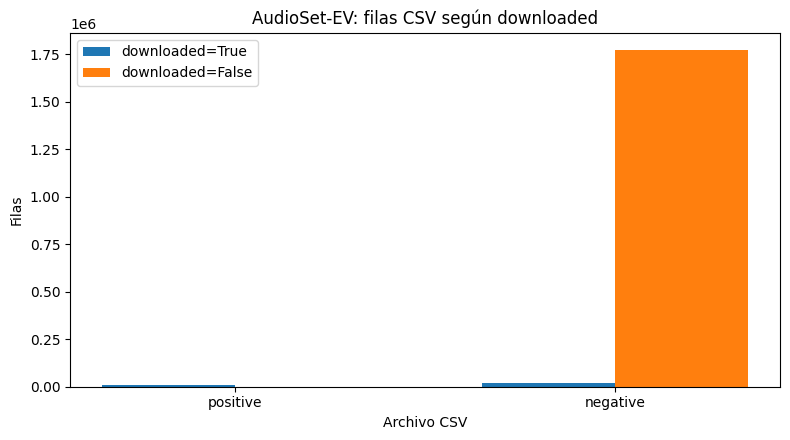

gráfico: /kaggle/working/dataset_audit_final/plots/audioset_downloaded.png


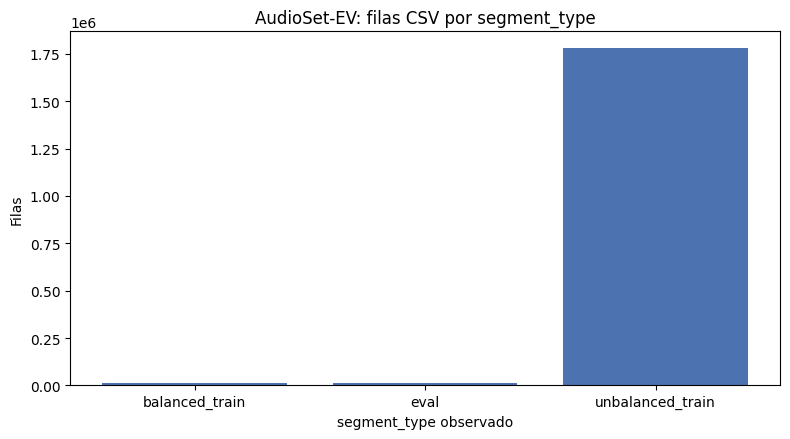

gráfico: /kaggle/working/dataset_audit_final/plots/audioset_segment_type.png


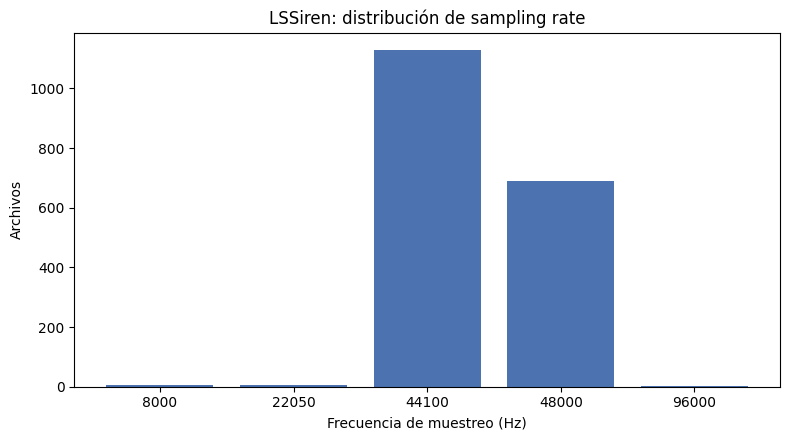

gráfico: /kaggle/working/dataset_audit_final/plots/lssiren_sampling_rate.png


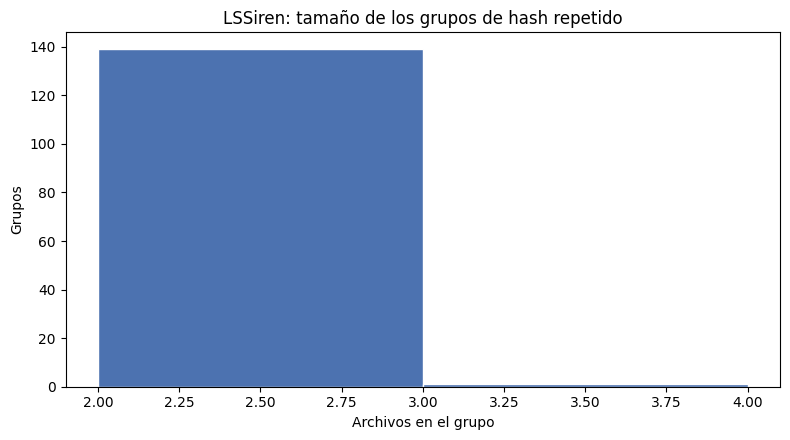

gráfico: /kaggle/working/dataset_audit_final/plots/lssiren_duplicate_group_sizes.png


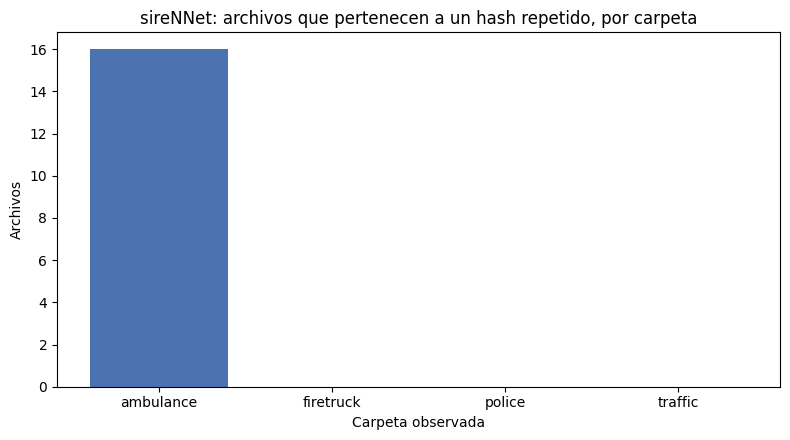

gráfico: /kaggle/working/dataset_audit_final/plots/sirennet_duplicates_by_class.png


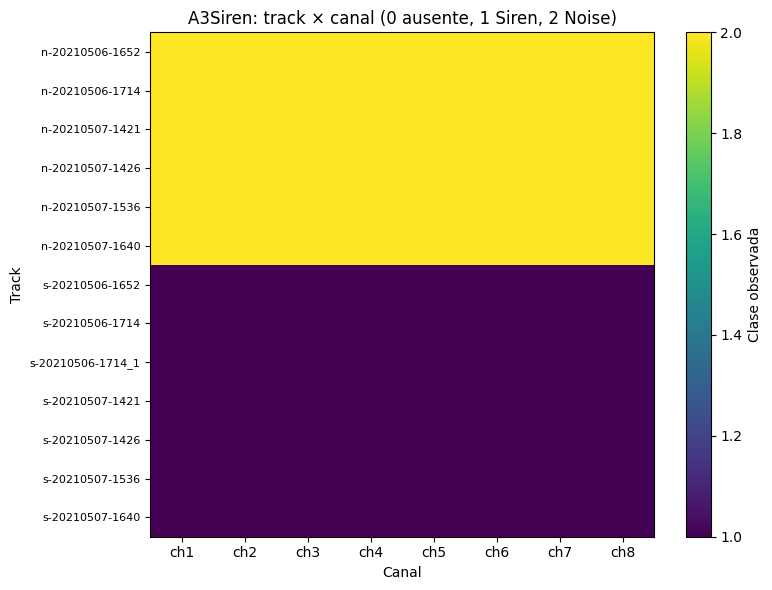

gráfico: /kaggle/working/dataset_audit_final/plots/a3siren_track_channel.png


In [22]:
def section_plots() -> None:
    counts = STATE["downloaded_counts"]
    if counts is not None and not counts.empty:
        fig, axis = plt.subplots(figsize=(8, 4.5))
        x = np.arange(len(counts))
        width = 0.35
        axis.bar(x - width / 2, counts["downloaded_true"], width, label="downloaded=True")
        axis.bar(x + width / 2, counts["downloaded_false"], width, label="downloaded=False")
        axis.set_xticks(x)
        axis.set_xticklabels(counts["side"])
        axis.set_title("AudioSet-EV: filas CSV según downloaded")
        axis.set_xlabel("Archivo CSV")
        axis.set_ylabel("Filas")
        axis.legend()
        save_figure(fig, "audioset_downloaded.png")
    segments = STATE.get("segment_summary", pd.DataFrame())
    if not segments.empty:
        grouped = segments.groupby("segment_type")[["csv_rows"]].sum().reset_index()
        fig, axis = plt.subplots(figsize=(8, 4.5))
        axis.bar(grouped["segment_type"], grouped["csv_rows"], color="#4C72B0")
        axis.set_title("AudioSet-EV: filas CSV por segment_type")
        axis.set_xlabel("segment_type observado")
        axis.set_ylabel("Filas")
        save_figure(fig, "audioset_segment_type.png")
    headers = STATE["headers"]
    quality = STATE["quality"]
    merged = headers.merge(quality[["dataset", "relative_path", "quality_status"]], on=["dataset", "relative_path"])
    lss = merged[(merged["dataset"] == "LSSiren") & (merged["quality_status"].isin(["OK", "WARNING"]))]
    rates = pd.to_numeric(lss["sampling_rate_hz"], errors="coerce").dropna().astype(int)
    if not rates.empty:
        counts = rates.value_counts().sort_index()
        fig, axis = plt.subplots(figsize=(8, 4.5))
        axis.bar([str(value) for value in counts.index], counts.values, color="#4C72B0")
        axis.set_title("LSSiren: distribución de sampling rate")
        axis.set_xlabel("Frecuencia de muestreo (Hz)")
        axis.set_ylabel("Archivos")
        save_figure(fig, "lssiren_sampling_rate.png")
    lssiren_dups = STATE.get("lssiren_dups", pd.DataFrame())
    if not lssiren_dups.empty and "file_count" in lssiren_dups.columns:
        fig, axis = plt.subplots(figsize=(8, 4.5))
        sizes = lssiren_dups["file_count"].astype(int)
        axis.hist(sizes, bins=range(int(sizes.min()), int(sizes.max()) + 2), color="#4C72B0", edgecolor="white")
        axis.set_title("LSSiren: tamaño de los grupos de hash repetido")
        axis.set_xlabel("Archivos en el grupo")
        axis.set_ylabel("Grupos")
        save_figure(fig, "lssiren_duplicate_group_sizes.png")
    siren = STATE.get("sirennet_dups", pd.DataFrame())
    per_class = {folder: 0 for folder in SIREN_FOLDERS}
    if not siren.empty and "paths" in siren.columns:
        for entry in siren["paths"]:
            for path in str(entry).split("|"):
                folder = sirennet_folder_of(path.strip())
                if folder in per_class:
                    per_class[folder] += 1
    fig, axis = plt.subplots(figsize=(8, 4.5))
    axis.bar(list(per_class), list(per_class.values()), color="#4C72B0")
    axis.set_title("sireNNet: archivos que pertenecen a un hash repetido, por carpeta")
    axis.set_xlabel("Carpeta observada")
    axis.set_ylabel("Archivos")
    save_figure(fig, "sirennet_duplicates_by_class.png")
    tracks = STATE.get("a3_tracks", pd.DataFrame())
    if not tracks.empty:
        channels = sorted(tracks["channel"].unique(), key=lambda value: int(re.search(r"\d+", value).group()))
        bases = sorted(tracks["base_name"].unique())
        matrix = np.zeros((len(bases), len(channels)))
        lookup = {(row.base_name, row.channel): 1 if str(row.class_observed).casefold() == "siren" else 2 for row in tracks.itertuples(index=False)}
        for i, base in enumerate(bases):
            for j, channel in enumerate(channels):
                matrix[i, j] = lookup.get((base, channel), 0)
        fig, axis = plt.subplots(figsize=(8, 6))
        image = axis.imshow(matrix, aspect="auto", cmap="viridis")
        axis.set_xticks(range(len(channels)))
        axis.set_xticklabels(channels)
        axis.set_yticks(range(len(bases)))
        axis.set_yticklabels(bases, fontsize=8)
        axis.set_title("A3Siren: track × canal (0 ausente, 1 Siren, 2 Noise)")
        axis.set_xlabel("Canal")
        axis.set_ylabel("Track")
        colorbar = fig.colorbar(image, ax=axis)
        colorbar.set_label("Clase observada")
        save_figure(fig, "a3siren_track_channel.png")

section_plots()


## 11. Validación frente a la Auditoría 00

Si un conteo no coincide con la corrida anterior, la notebook lo registra como diferencia y no lo oculta.


In [23]:
def section_validate_and_print() -> None:
    comparison = compare_with_audit00(STATE["inventory"])
    export_table(comparison, "audit00_count_comparison.csv")
    counts = STATE["downloaded_counts"]
    true_total = int(counts["downloaded_true"].sum()) if counts is not None and not counts.empty else 0
    false_total = int(counts["downloaded_false"].sum()) if counts is not None and not counts.empty else 0
    manifest = STATE["manifest"]
    internal = 0
    for dataset_name, group in manifest.groupby("dataset"):
        sizes = group.loc[group["sha256"].astype(str) != ""].groupby("sha256").size()
        internal += int(sizes[sizes > 1].sum())
    exact = 0
    if "overlap" in STATE and not STATE["overlap"].empty:
        exact = int((STATE["overlap"]["match_type"] == "EXACT_MATCH").sum())
    ready = STATE["readiness"]
    ready_names = ready.loc[ready["ready_for_eda"] == "YES", "dataset"].tolist()
    pending = int((STATE["issues"]["resolved"] == "NO").sum()) if "issues" in STATE else 0
    rates = sampling_text(STATE["headers"], "LSSiren", STATE["quality"])
    tracks = int(STATE["a3_tracks"]["base_name"].nunique()) if "a3_tracks" in STATE and not STATE["a3_tracks"].empty else 0
    valid = int(STATE["quality"]["quality_status"].isin(["OK", "WARNING"]).sum())
    invalid = int((STATE["quality"]["quality_status"] == "ERROR").sum())
    payload = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "seed": RANDOM_SEED,
        "input_root": str(INPUT_ROOT),
        "output_root": str(OUTPUT_ROOT),
        "total_files": int(len(STATE["inventory"])),
        "valid_files": valid,
        "invalid_files": invalid,
        "internal_duplicated_files": internal,
        "exact_cross_dataset_hash_groups": exact,
        "a3_logical_tracks": tracks,
        "audioset_downloaded_true": true_total,
        "audioset_downloaded_false": false_total,
        "datasets_ready_for_eda": ready_names,
        "pending_issue_rows": pending,
        "markdown_files_written": False,
        "differences_vs_audit00": comparison.loc[comparison["difference"] == "YES", "metric"].tolist(),
    }
    (OUTPUT_ROOT / "19_audit_final_status.json").write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print("escrito:", OUTPUT_ROOT / "19_audit_final_status.json")
    print("========================================")
    print("FINAL DATASET AUDIT")
    print("========================================")
    print("Datasets:")
    print("AudioSet-EV v2")
    print("LSSiren")
    print("sireNNet")
    print("A3Siren-Recordings")
    print()
    print("Total files:")
    print(f"{len(STATE['inventory']):,}")
    print()
    print("Valid:")
    print(f"{valid:,}")
    print()
    print("Invalid:")
    print(f"{invalid:,}")
    print()
    print("Internal duplicated files:")
    print(internal)
    print()
    print("Exact cross-dataset matches:")
    print(exact)
    print()
    print("A3Siren logical tracks:")
    print(tracks)
    print()
    print("AudioSet-EV downloaded=True:")
    print(true_total)
    print()
    print("AudioSet-EV downloaded=False:")
    print(false_total)
    print()
    print("LSSiren sampling rates:")
    print(rates)
    print()
    print("Datasets ready for EDA:")
    print(", ".join(ready_names) if ready_names else "(ninguno)")
    print()
    print("Pending issues:")
    print(pending)
    print("========================================")
    print("No se eligió un dataset principal. Los informes Markdown se redactan después de esta ejecución.")
    if payload["differences_vs_audit00"]:
        raise AssertionError(
            "Diferencia detectada respecto de Auditoría 00: " + ", ".join(payload["differences_vs_audit00"])
        )

section_validate_and_print()


Los conteos coinciden con la Auditoría 00.
escrito: /kaggle/working/dataset_audit_final/audit00_count_comparison.csv
escrito: /kaggle/working/dataset_audit_final/19_audit_final_status.json
FINAL DATASET AUDIT
Datasets:
AudioSet-EV v2
LSSiren
sireNNet
A3Siren-Recordings

Total files:
32,429

Valid:
32,427

Invalid:
2

Internal duplicated files:
332

Exact cross-dataset matches:
0

A3Siren logical tracks:
13

AudioSet-EV downloaded=True:
28816

AudioSet-EV downloaded=False:
1773818

LSSiren sampling rates:
8000 Hz=5 (0.3%); 22050 Hz=6 (0.3%); 44100 Hz=1130 (61.6%); 48000 Hz=691 (37.7%); 96000 Hz=2 (0.1%)

Datasets ready for EDA:
AudioSet-EV v2, LSSiren, sireNNet, A3Siren-Recordings

Pending issues:
14
No se eligió un dataset principal. Los informes Markdown se redactan después de esta ejecución.
